# Lab 2: Federated Learning — Parameter Sweeps Analysis
Comparing **MLP** and **Logistic Regression** across local epochs, client ratios, and more.

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

cwd = Path.cwd()
if (cwd / 'runs').exists():
    base_dir = cwd / 'runs'
elif cwd.name == 'runs':
    base_dir = cwd
else:
    base_dir = cwd / 'runs'

plot_dir = base_dir / 'plots' / 'lab_2'
plot_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(plot_dir / name, dpi=200, bbox_inches='tight')
    print(f"Saved plot: {plot_dir / name}")

## 1. Data Loading Helper Functions

In [2]:
def load_global_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the global metrics (like accuracy per round)."""
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv' # Fallback
    
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    return None

def load_locals_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the per-client local metrics."""
    path = run_path / 'locals_metrics.csv'
    return pd.read_csv(path) if path.exists() else None

def load_comm_costs(run_path: Path):
    """Loads communication costs."""
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    """Loads the total run time in seconds."""
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return 0.0
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    return float(row['value'].iloc[0]) if not row.empty else 0.0

def comm_to_mb(comm_df):
    """Converts communication costs from bytes/parameters to Megabytes."""
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / (1024**2)

def get_final_metric(run_path: Path, metric: str):
    """Gets the final-round value of a metric."""
    df = load_global_metrics(Path(run_path))
    if df is not None and metric in df.columns:
        return df[metric].iloc[-1]
    return None

def get_best_metric(run_path: Path, metric: str):
    """Gets the best (max) value of a metric."""
    df = load_global_metrics(Path(run_path))
    if df is not None and metric in df.columns:
        return df[metric].max()
    return None

## 2. Generic Plotting Functions

In [3]:
MODEL_COLORS = {
    'MLP': '#2196F3',
    'LogReg': '#F44336',
}

LINESTYLES = ['-', '--', '-.', ':']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']


def plot_evolution_metric(experiments_dict, metric='accuracy', title='Model Comparison',
                          filename='evolution.png', ylabel=None, mark_every=5):
    """Plots a line chart of a given metric (e.g., accuracy) over communication rounds."""
    plt.figure(figsize=(12, 7))
    cm = plt.get_cmap('tab10')
    
    plotted_any = False
    
    for i, (path, label) in enumerate(experiments_dict.items()):
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            color = cm(i % 10)
            l_style = LINESTYLES[i % len(LINESTYLES)]
            marker = MARKERS[i % len(MARKERS)]
            
            plt.plot(df['round'], df[metric], 
                     color=color, linestyle=l_style, linewidth=2, label=str(label),
                     marker=marker, markersize=4, markevery=mark_every)
            plotted_any = True
        else:
            print(f"\u26a0\ufe0f Warning: Could not load metric '{metric}' for '{label}' at {path}")
            
    if plotted_any:
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Communication Round', fontsize=12)
        plt.ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_fig(filename)
        plt.show()
    else:
        print("No data available to plot.")


def plot_cost_summary(experiments_dict, title='Cost Summary', filename='costs.png'):
    """Plots a dual-axis bar chart comparing Time (seconds) and Comm Costs (MB)."""
    times = []
    comms = []
    valid_labels = []
    
    for path, label in experiments_dict.items():
        p = Path(path)
        if not p.exists():
            print(f"\u26a0\ufe0f Warning: Path not found: {p}")
            continue
            
        times.append(load_run_time(p))
        comms.append(comm_to_mb(load_comm_costs(p)))
        valid_labels.append(str(label))
        
    if not times:
        print("No data to plot for costs.")
        return

    x = np.arange(len(valid_labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(max(10, len(valid_labels) * 1.8), 7))

    # Time (Left Y-Axis)
    color1 = '#E76F51' # Orange/Red
    ax1.set_xlabel('Experiment Configuration', fontsize=12)
    ax1.set_ylabel('Total Time (s)', color=color1, fontsize=12)
    rects1 = ax1.bar(x - width/2, times, width, label='Time (s)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Add time values on top of bars
    for bar in rects1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}s', 
                 ha='center', va='bottom', fontsize=10, color=color1)

    # Communication (Right Y-Axis)
    ax2 = ax1.twinx()  
    color2 = '#2A9D8F'
    ax2.set_ylabel('Total Communication (MB)', color=color2, fontsize=12)  
    rects2 = ax2.bar(x + width/2, comms, width, label='Comm (MB)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    for bar in rects2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', 
                 ha='center', va='bottom', fontsize=10, color=color2)

    ax1.set_xticks(x)
    ax1.set_xticklabels(valid_labels, rotation=45, ha="right")
    plt.title(title, fontsize=14, fontweight='bold')
    fig.tight_layout()  
    save_fig(filename)
    plt.show()


def plot_bar_comparison(experiments_dict, metric='accuracy', title='Comparison',
                        filename='bar.png', ylabel=None, use_final_round=True):
    """Plots a bar chart comparing the final (or best) value of a metric across experiments."""
    values = []
    labels = []

    for path, label in experiments_dict.items():
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            if use_final_round:
                val = df[metric].iloc[-1]
            else:
                val = df[metric].max()
            values.append(val)
            labels.append(str(label))

    if not values:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.5), 6))
    cm = plt.get_cmap('tab10')
    colors = [cm(i % 10) for i in range(len(labels))]
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_utility_vs_cost(experiments_dict, utility_metric='accuracy',
                         title='Utility vs Cost', filename='utility_vs_cost.png'):
    """Scatter plot: accuracy (utility) vs training time (cost)."""
    fig, ax = plt.subplots(figsize=(10, 7))
    cm = plt.get_cmap('tab10')

    for i, (path, label) in enumerate(experiments_dict.items()):
        p = Path(path)
        df = load_global_metrics(p)
        t = load_run_time(p)
        if df is not None and utility_metric in df.columns and t > 0:
            final_val = df[utility_metric].iloc[-1]
            color = cm(i % 10)
            marker = MARKERS[i % len(MARKERS)]
            ax.scatter(t, final_val, color=color, marker=marker, s=200, label=str(label),
                       edgecolors='black', linewidths=0.8, zorder=5)
            ax.annotate(str(label), (t, final_val), textcoords='offset points',
                        xytext=(10, 5), fontsize=9)

    ax.set_xlabel('Training Time (s) \u2014 Cost', fontsize=12)
    ax.set_ylabel(f'{utility_metric.replace("_", " ").title()} \u2014 Utility', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_metric_vs_param(model_data, param_name, metric, title, filename,
                         ylabel=None, use_best=False):
    """
    Generic: plot a metric against a swept parameter for both models side-by-side.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name, entries in model_data.items():
        params = []
        values = []
        for param_val, run_path in sorted(entries, key=lambda x: x[0]):
            p = Path(run_path)
            if use_best:
                val = get_best_metric(p, metric)
            else:
                val = get_final_metric(p, metric)
            if val is not None:
                params.append(param_val)
                values.append(val)

        if params:
            color = MODEL_COLORS.get(model_name, '#666666')
            ax.plot(params, values, color=color, linewidth=2.5, label=model_name,
                    marker='o', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
            for pv, vv in zip(params, values):
                ax.annotate(f'{vv:.4f}', (pv, vv), textcoords='offset points',
                            xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_time_vs_param(model_data, param_name, title, filename):
    """
    Plot training time against a swept parameter for both models.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name, entries in model_data.items():
        params = []
        times = []
        for param_val, run_path in sorted(entries, key=lambda x: x[0]):
            p = Path(run_path)
            t = load_run_time(p)
            if t > 0:
                params.append(param_val)
                times.append(t)

        if params:
            color = MODEL_COLORS.get(model_name, '#666666')
            ax.plot(params, times, color=color, linewidth=2.5, label=model_name,
                    marker='s', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
            for pv, tv in zip(params, times):
                ax.annotate(f'{tv:.1f}s', (pv, tv), textcoords='offset points',
                            xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel('Training Time (s)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_grouped_bars(model_data, param_name, metric, title, filename,
                      ylabel=None, use_best=False):
    """
    Grouped bar chart: one group per param value, bars for each model.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    all_params = sorted(set(
        pv for entries in model_data.values() for pv, _ in entries
    ))
    model_names = list(model_data.keys())
    n_models = len(model_names)
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(all_params) * 2), 6))
    x = np.arange(len(all_params))

    for mi, model_name in enumerate(model_names):
        lookup = {}
        for pv, rp in model_data[model_name]:
            p = Path(rp)
            if use_best:
                val = get_best_metric(p, metric)
            else:
                val = get_final_metric(p, metric)
            if val is not None:
                lookup[pv] = val

        vals = [lookup.get(pv, 0) for pv in all_params]
        offset = (mi - (n_models - 1) / 2) * width
        color = MODEL_COLORS.get(model_name, plt.get_cmap('tab10')(mi))
        bars = ax.bar(x + offset, vals, width * 0.9, label=model_name, color=color,
                       edgecolor='white', linewidth=1)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(p) for p in all_params])
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig(filename)
    plt.show()

## 3. Define the Experiments to Compare

In [4]:
# ── MLP: Local Epochs sweep ──
mlp_epochs_experiments = {
    base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_5_epoch": "MLP 5 ep",
    base_dir / "lab_2_tabular_MLP_experiment_10_epoch": "MLP 10 ep (Base)", 
    base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_15_epoch": "MLP 15 ep",
    base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_20_epoch": "MLP 20 ep",
}

# ── MLP: Client Ratio sweep ──
mlp_ratio_experiments = {
    base_dir / "client_ratio" / "lab_2_tabular_MLP_experiment_ratio_25": "MLP 25%",
    base_dir / "client_ratio" / "lab_2_tabular_MLP_experiment_ratio_50": "MLP 50%",
    base_dir / "lab_2_tabular_MLP_experiment_10_epoch": "MLP 100% (Base)" 
}

# ── LogReg: Local Epochs sweep ──
logreg_epochs_experiments = {
    base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_5_epoch": "LogReg 5 ep",
    base_dir / "lab_2_tabular_LogReg_experiment_10_epoch": "LogReg 10 ep (Base)",
    base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_15_epoch": "LogReg 15 ep",
    base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_20_epoch": "LogReg 20 ep"
}

# ── LogReg: Client Ratio sweep ──
logreg_ratio_experiments = {
    base_dir / "client_ratio" / "lab_2_tabular_LogReg_experiment_ratio_25": "LogReg 25%",
    base_dir / "client_ratio" / "lab_2_tabular_LogReg_experiment_ratio_50": "LogReg 50%",
    base_dir / "lab_2_tabular_LogReg_experiment_10_epoch": "LogReg 100% (Base)" 
}

# ── Combined: all experiments for cross-model comparison ──
all_experiments = {**mlp_epochs_experiments, **logreg_epochs_experiments}
all_ratio_experiments = {**mlp_ratio_experiments, **logreg_ratio_experiments}

# ── Base models only (10 epoch, 100% ratio) ──
base_experiments = {
    base_dir / "lab_2_tabular_MLP_experiment_10_epoch": "MLP (Base)",
    base_dir / "lab_2_tabular_LogReg_experiment_10_epoch": "LogReg (Base)",
}

# ── Structured data for param-sweep plots ──
# epochs sweep
epochs_by_model = {
    'MLP': [
        (5,  base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_5_epoch"),
        (10, base_dir / "lab_2_tabular_MLP_experiment_10_epoch"),
        (15, base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_15_epoch"),
        (20, base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_20_epoch"),
    ],
    'LogReg': [
        (5,  base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_5_epoch"),
        (10, base_dir / "lab_2_tabular_LogReg_experiment_10_epoch"),
        (15, base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_15_epoch"),
        (20, base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_20_epoch"),
    ],
}

# We map client ratio percentages to an approximate n_clients value.
# Ratio 25% / 50% / 100% — we use % as the x-axis label.
ratio_by_model = {
    'MLP': [
        (25,  base_dir / "client_ratio" / "lab_2_tabular_MLP_experiment_ratio_25"),
        (50,  base_dir / "client_ratio" / "lab_2_tabular_MLP_experiment_ratio_50"),
        (100, base_dir / "lab_2_tabular_MLP_experiment_10_epoch"),
    ],
    'LogReg': [
        (25,  base_dir / "client_ratio" / "lab_2_tabular_LogReg_experiment_ratio_25"),
        (50,  base_dir / "client_ratio" / "lab_2_tabular_LogReg_experiment_ratio_50"),
        (100, base_dir / "lab_2_tabular_LogReg_experiment_10_epoch"),
    ],
}

print("Lab 2 experiments loaded.")
for name, d in [('MLP epochs', mlp_epochs_experiments), ('LogReg epochs', logreg_epochs_experiments),
                ('MLP ratio', mlp_ratio_experiments), ('LogReg ratio', logreg_ratio_experiments)]:
    print(f"\n{name}:")
    for p, l in d.items():
        exists = '\u2705' if Path(p).exists() else '\u274c'
        print(f"  {exists} {l}: {p}")

Lab 2 experiments loaded.

MLP epochs:
  ✅ MLP 5 ep: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/local_epochs/lab_2_tabular_MLP_experiment_5_epoch
  ✅ MLP 10 ep (Base): /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/lab_2_tabular_MLP_experiment_10_epoch
  ✅ MLP 15 ep: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/local_epochs/lab_2_tabular_MLP_experiment_15_epoch
  ✅ MLP 20 ep: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/local_epochs/lab_2_tabular_MLP_experiment_20_epoch

LogReg epochs:
  ✅ LogReg 5 ep: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/local_epochs/lab_2_tabular_LogReg_experiment_5_epoch
  ✅ LogReg 10 ep (Base): /home/romain/dev/Master/feder

---
## 4. Accuracy & F1 over FL Rounds
### 4.1 MLP — Local Epochs

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_epochs_accuracy.png


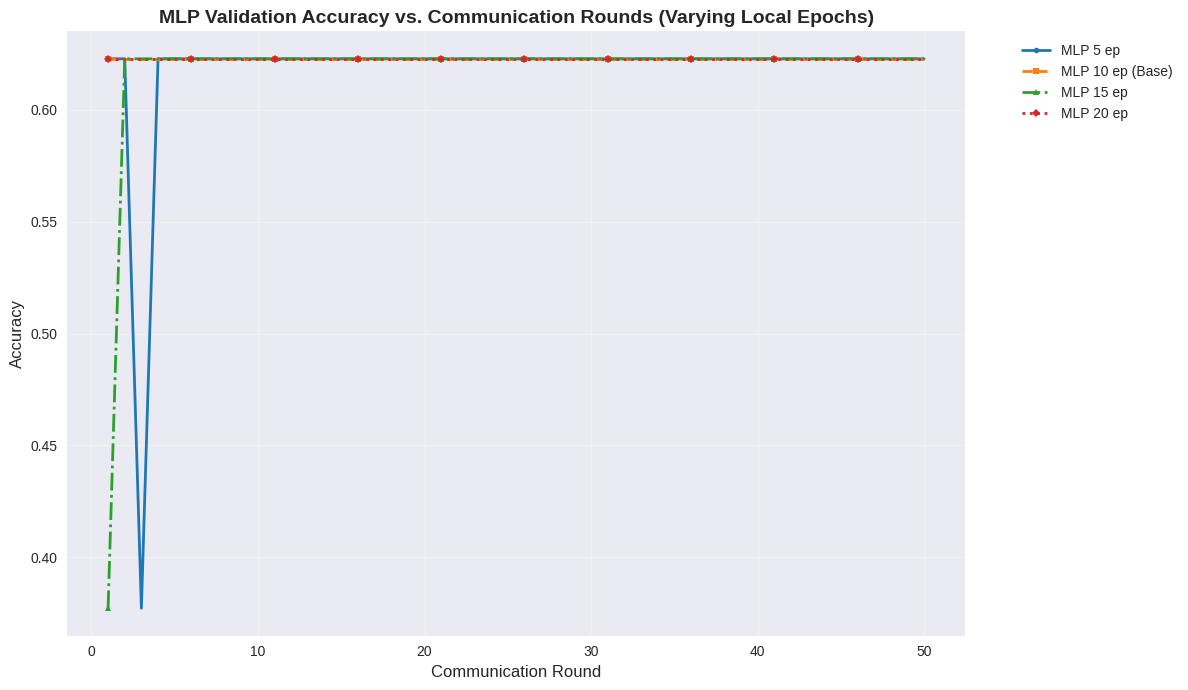

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_epochs_macro_f1.png


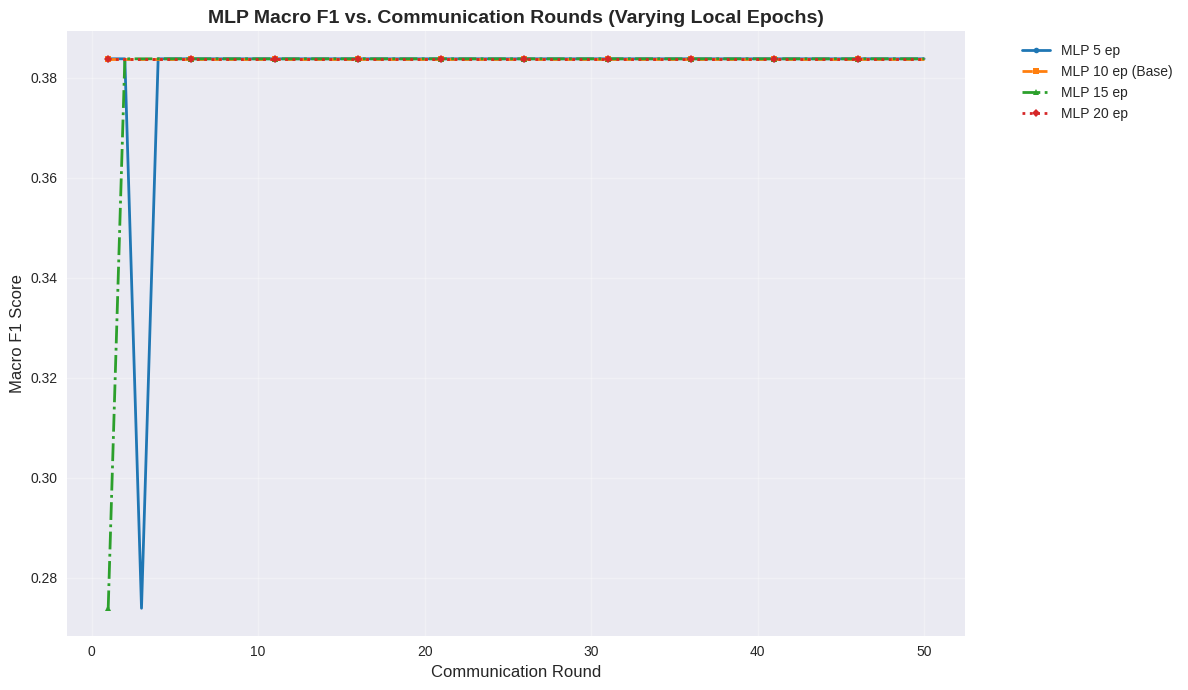

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_epochs_micro_f1.png


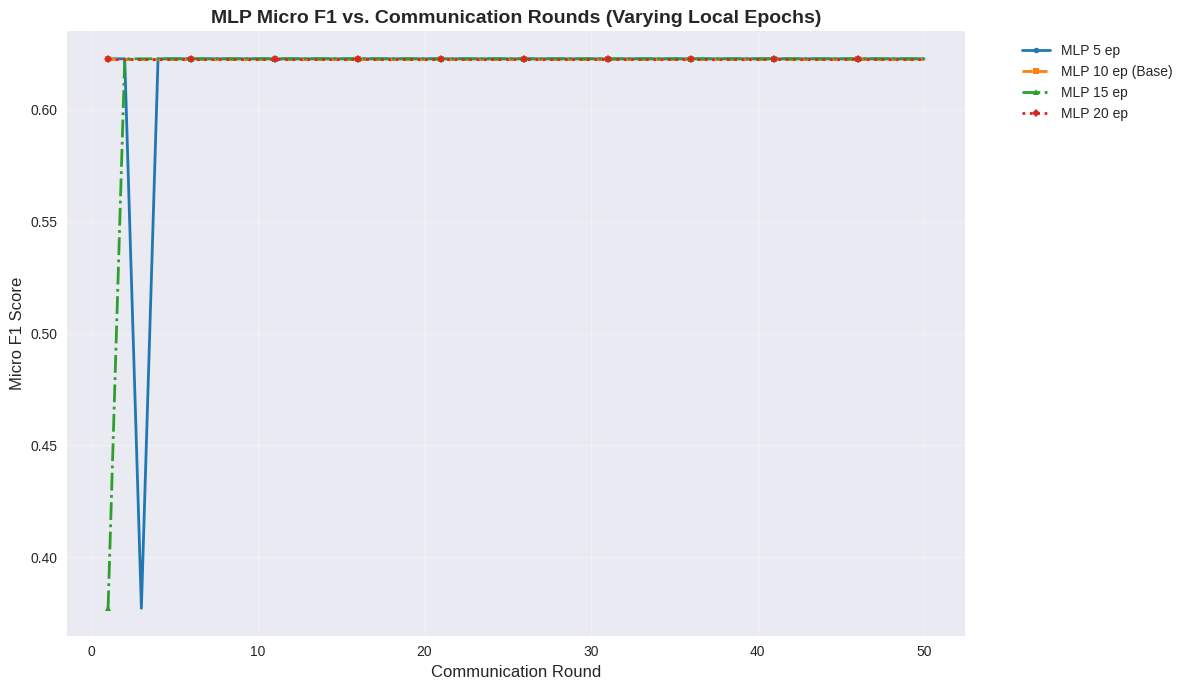

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_epochs_costs.png


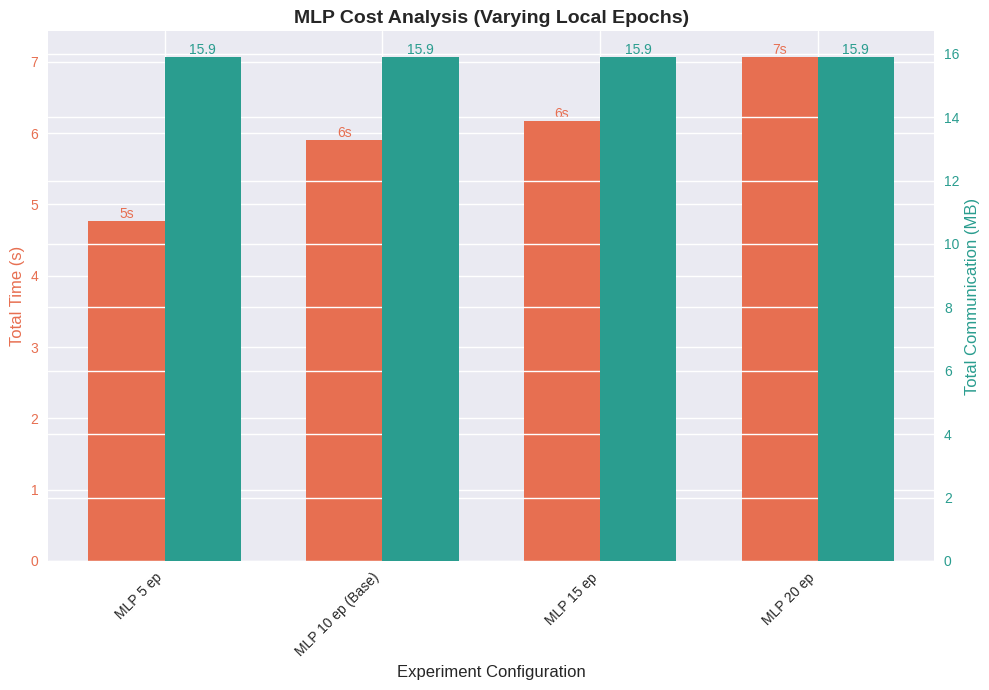

In [5]:
# MLP Local Epochs Analysis
plot_evolution_metric(mlp_epochs_experiments, metric='accuracy', 
                      title='MLP Validation Accuracy vs. Communication Rounds (Varying Local Epochs)', 
                      filename='mlp_epochs_accuracy.png',
                      ylabel='Accuracy')

plot_evolution_metric(mlp_epochs_experiments, metric='macro_f1',
                      title='MLP Macro F1 vs. Communication Rounds (Varying Local Epochs)',
                      filename='mlp_epochs_macro_f1.png',
                      ylabel='Macro F1 Score')

plot_evolution_metric(mlp_epochs_experiments, metric='micro_f1',
                      title='MLP Micro F1 vs. Communication Rounds (Varying Local Epochs)',
                      filename='mlp_epochs_micro_f1.png',
                      ylabel='Micro F1 Score')

plot_cost_summary(mlp_epochs_experiments,
                  title='MLP Cost Analysis (Varying Local Epochs)',
                  filename='mlp_epochs_costs.png')

### 4.2 MLP — Client Ratio

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_ratio_accuracy.png


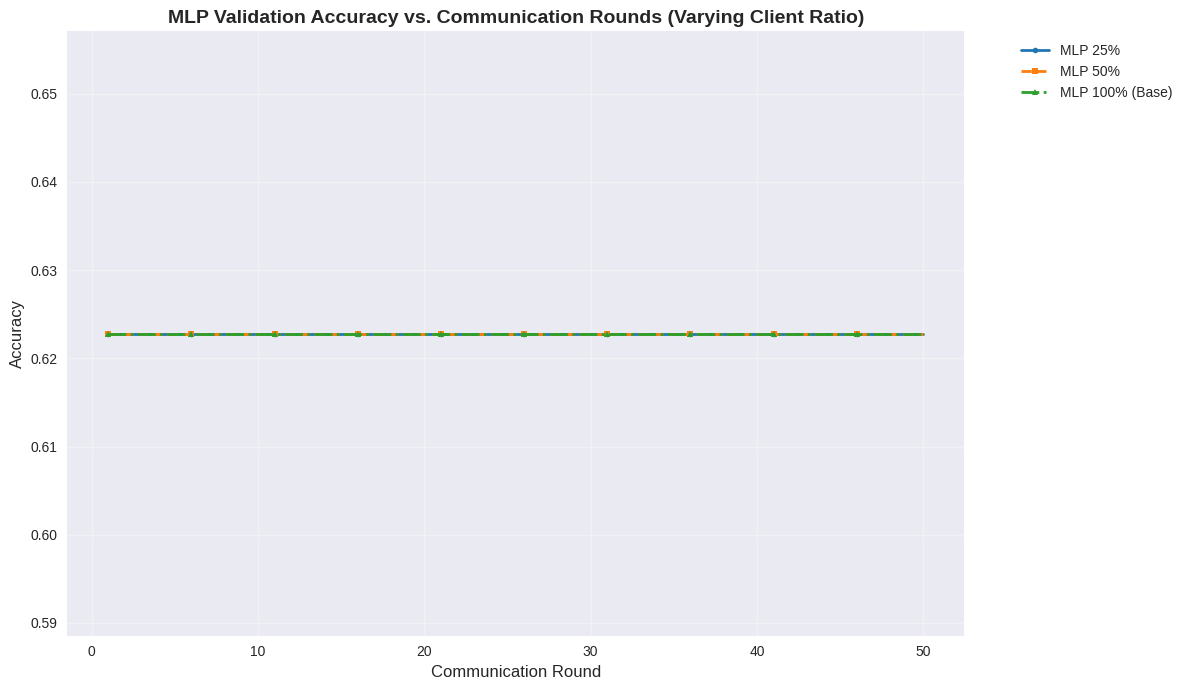

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_ratio_macro_f1.png


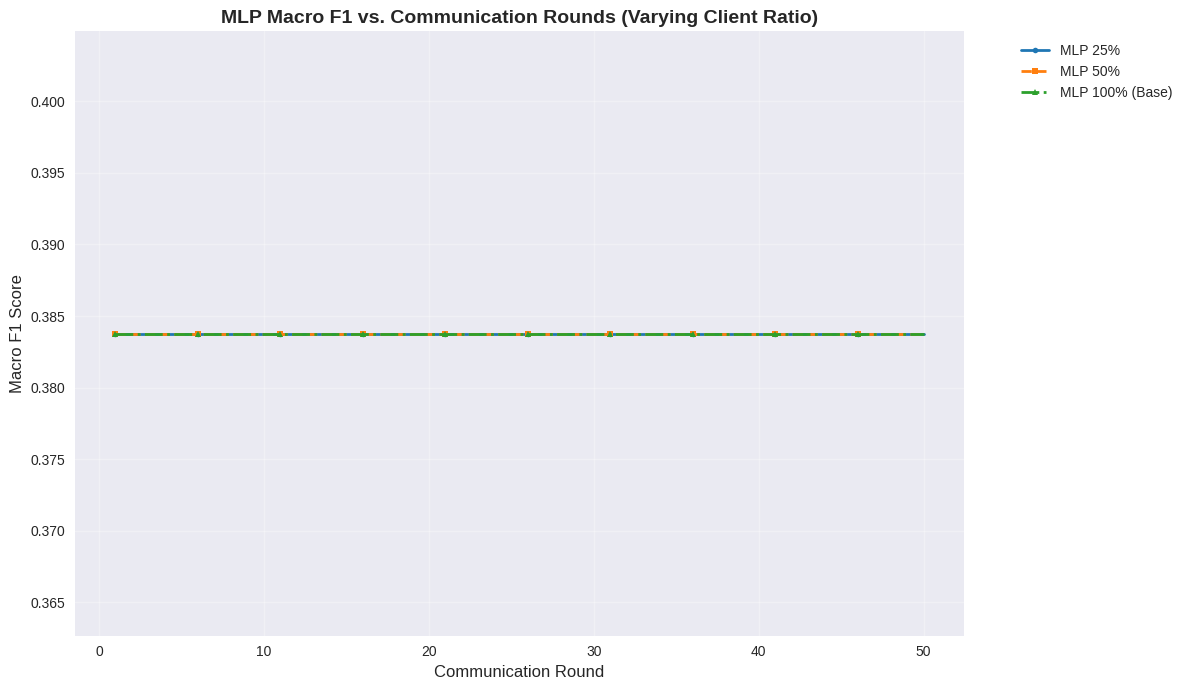

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_ratio_micro_f1.png


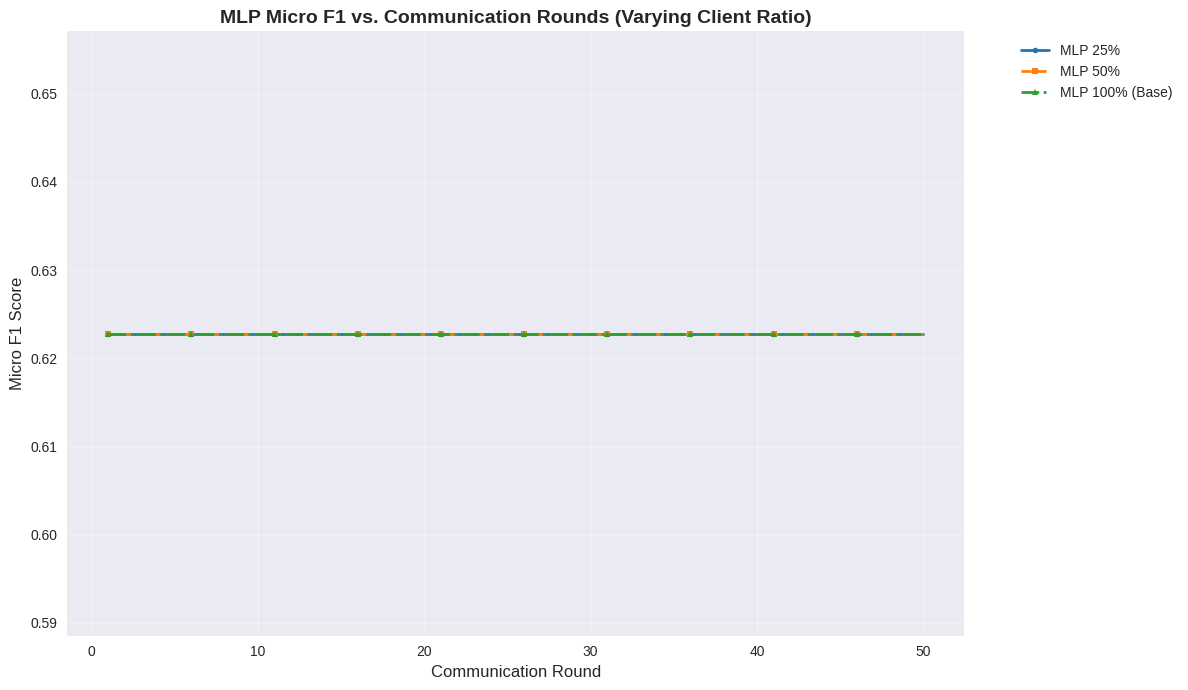

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/mlp_ratio_costs.png


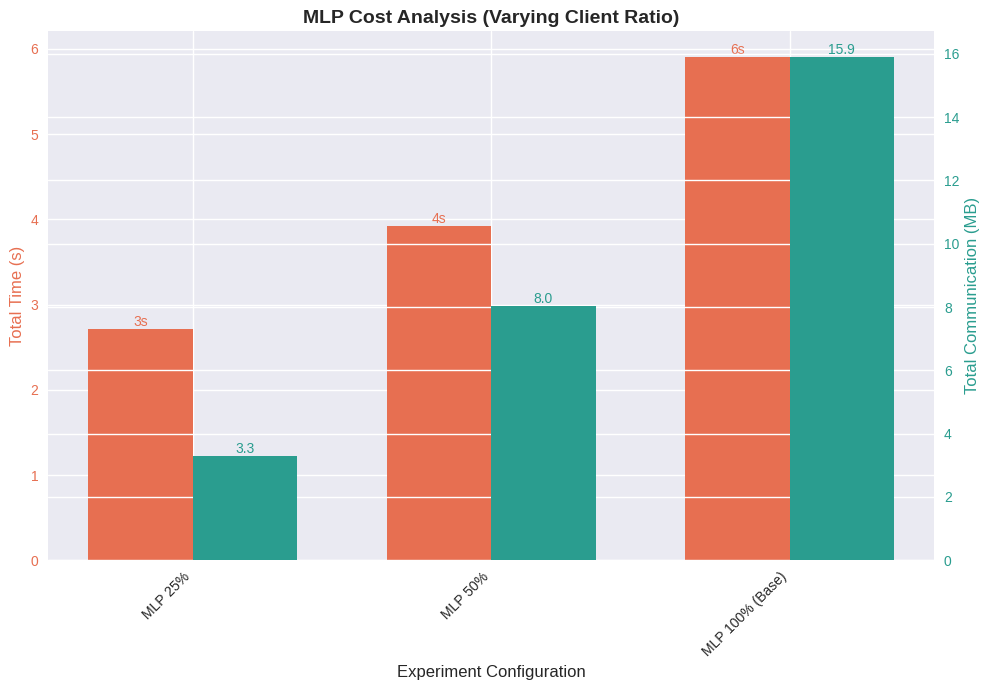

In [6]:
# MLP Client Ratio Analysis
plot_evolution_metric(mlp_ratio_experiments, metric='accuracy', 
                      title='MLP Validation Accuracy vs. Communication Rounds (Varying Client Ratio)', 
                      filename='mlp_ratio_accuracy.png',
                      ylabel='Accuracy')

plot_evolution_metric(mlp_ratio_experiments, metric='macro_f1',
                      title='MLP Macro F1 vs. Communication Rounds (Varying Client Ratio)',
                      filename='mlp_ratio_macro_f1.png',
                      ylabel='Macro F1 Score')

plot_evolution_metric(mlp_ratio_experiments, metric='micro_f1',
                      title='MLP Micro F1 vs. Communication Rounds (Varying Client Ratio)',
                      filename='mlp_ratio_micro_f1.png',
                      ylabel='Micro F1 Score')

plot_cost_summary(mlp_ratio_experiments,
                  title='MLP Cost Analysis (Varying Client Ratio)',
                  filename='mlp_ratio_costs.png')

### 4.3 LogReg — Local Epochs

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_epochs_accuracy.png


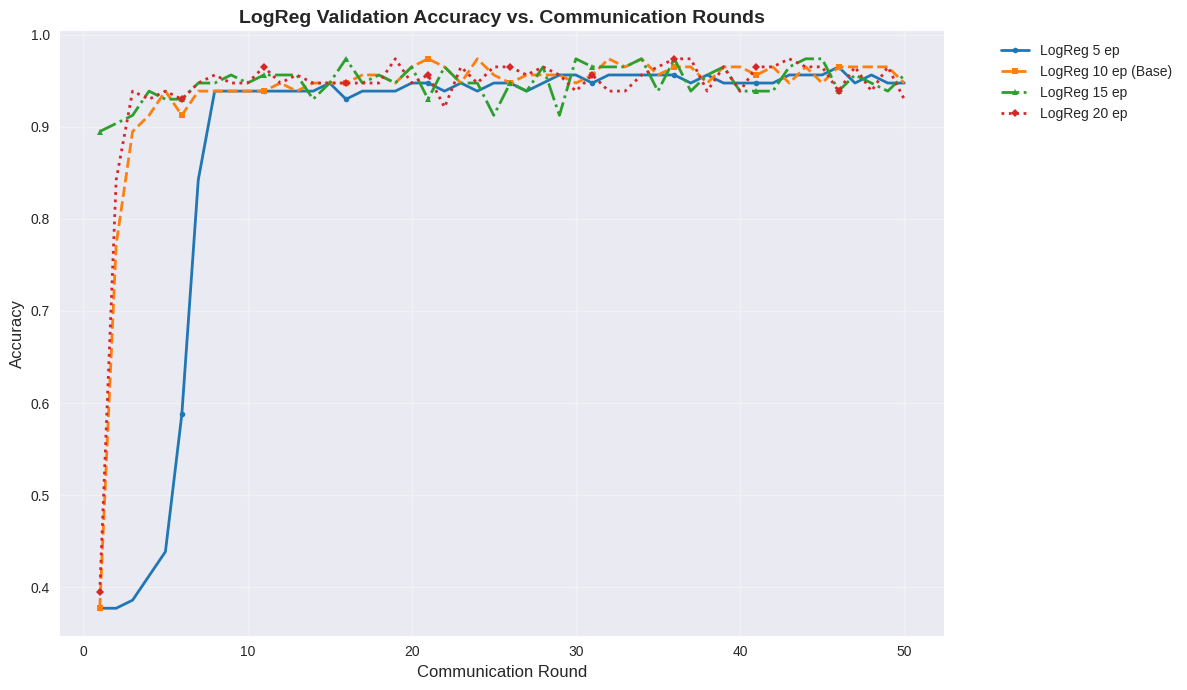

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_epochs_macro_f1.png


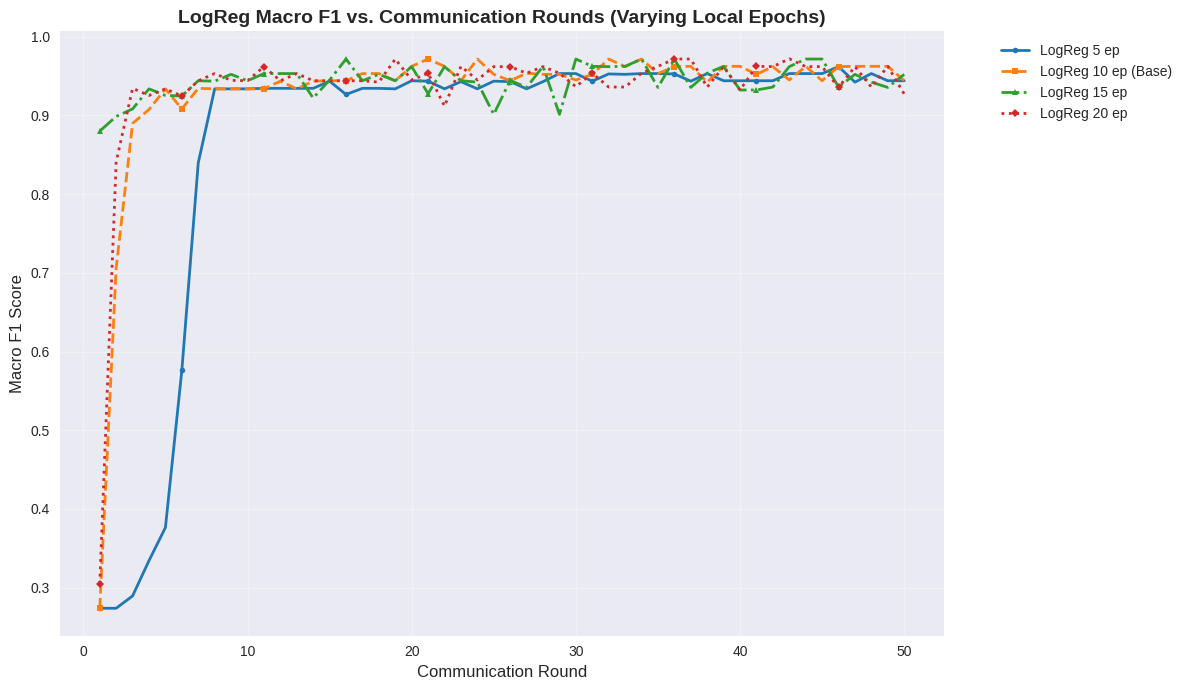

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_epochs_micro_f1.png


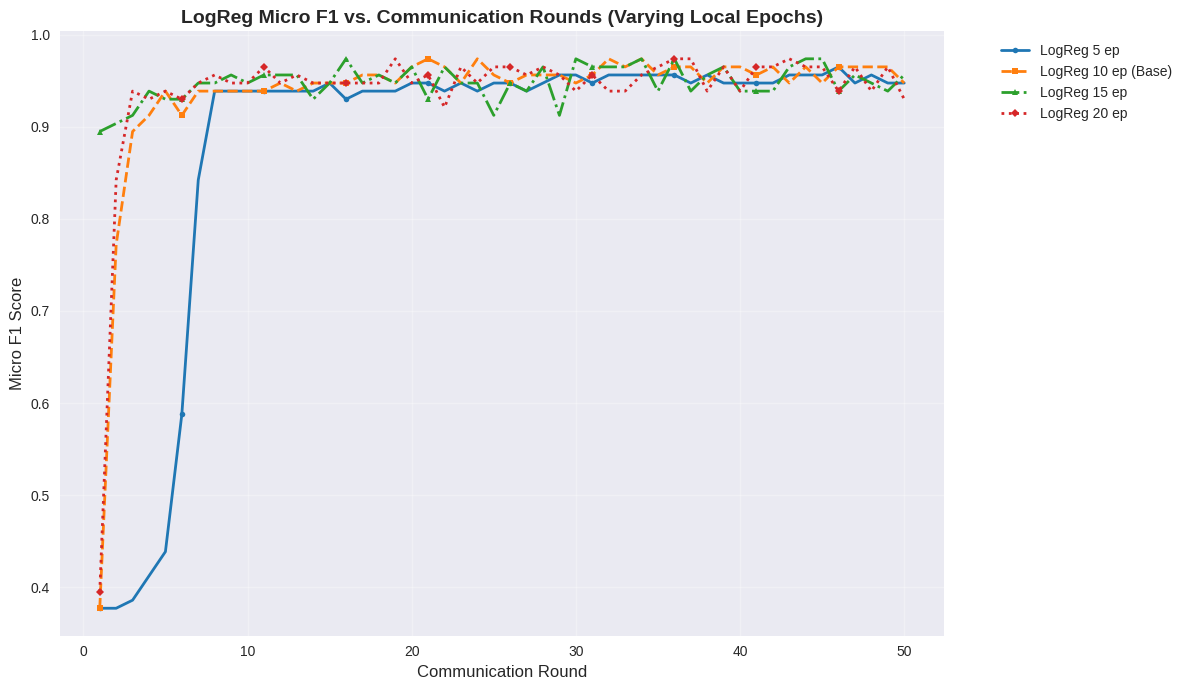

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_epochs_costs.png


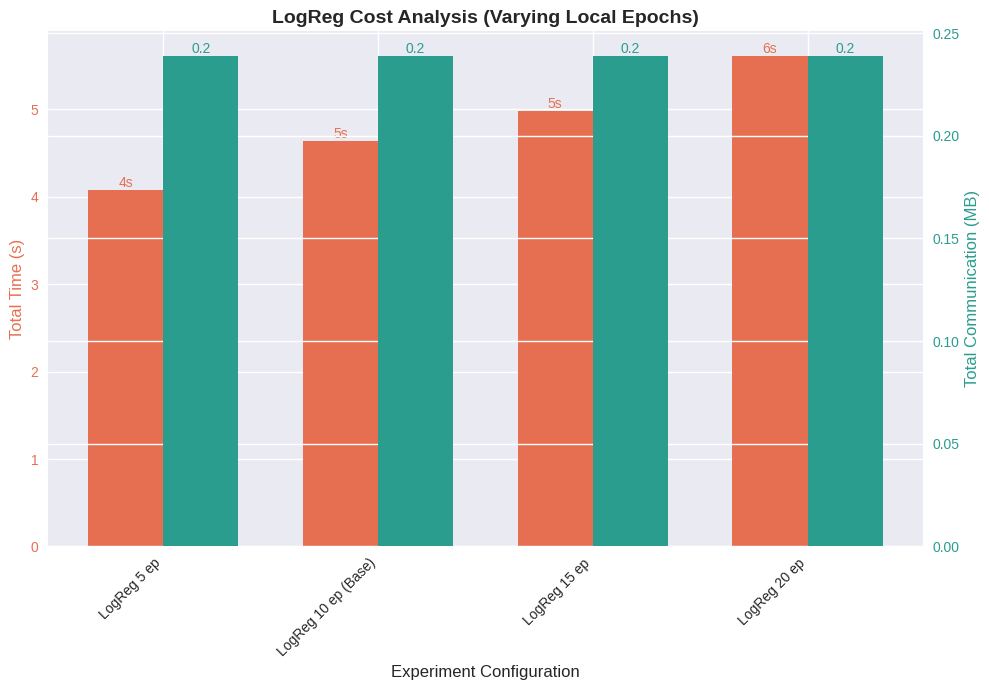

In [7]:
# LogReg Local Epochs Analysis
plot_evolution_metric(logreg_epochs_experiments, metric='accuracy', 
                      title='LogReg Validation Accuracy vs. Communication Rounds',
                      filename='logreg_epochs_accuracy.png',
                      ylabel='Accuracy')

plot_evolution_metric(logreg_epochs_experiments, metric='macro_f1',
                      title='LogReg Macro F1 vs. Communication Rounds (Varying Local Epochs)',
                      filename='logreg_epochs_macro_f1.png',
                      ylabel='Macro F1 Score')

plot_evolution_metric(logreg_epochs_experiments, metric='micro_f1',
                      title='LogReg Micro F1 vs. Communication Rounds (Varying Local Epochs)',
                      filename='logreg_epochs_micro_f1.png',
                      ylabel='Micro F1 Score')

plot_cost_summary(logreg_epochs_experiments,
                  title='LogReg Cost Analysis (Varying Local Epochs)',
                  filename='logreg_epochs_costs.png')

### 4.4 LogReg — Client Ratio

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_ratio_accuracy.png


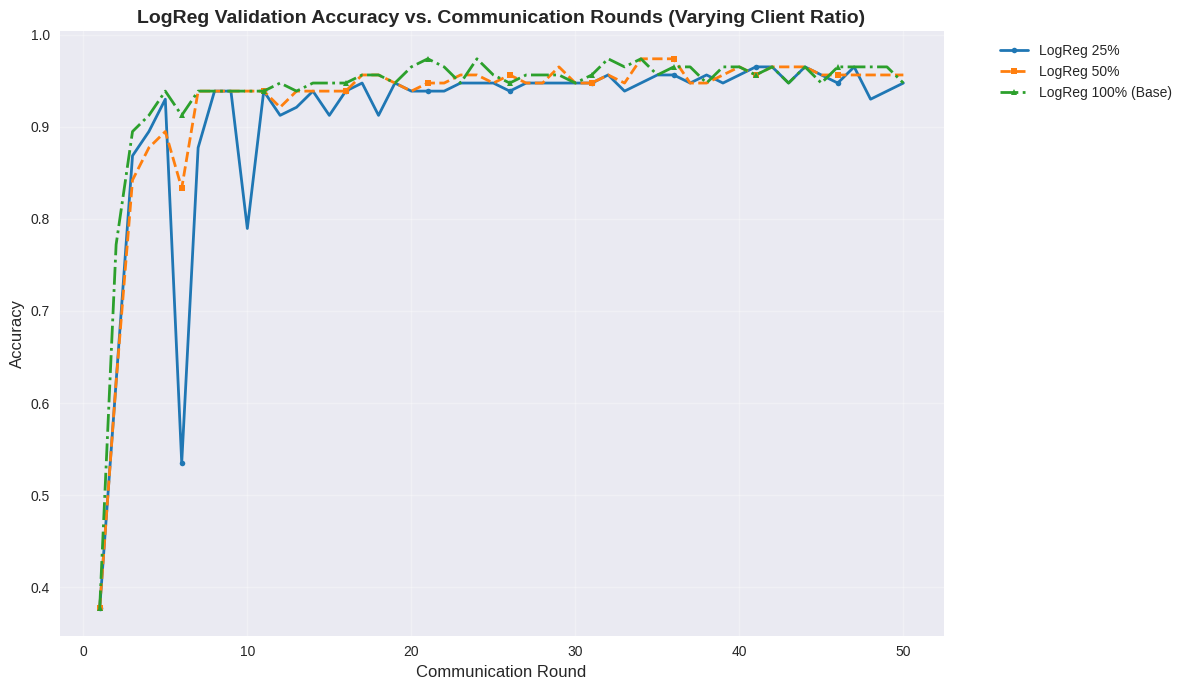

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_ratio_macro_f1.png


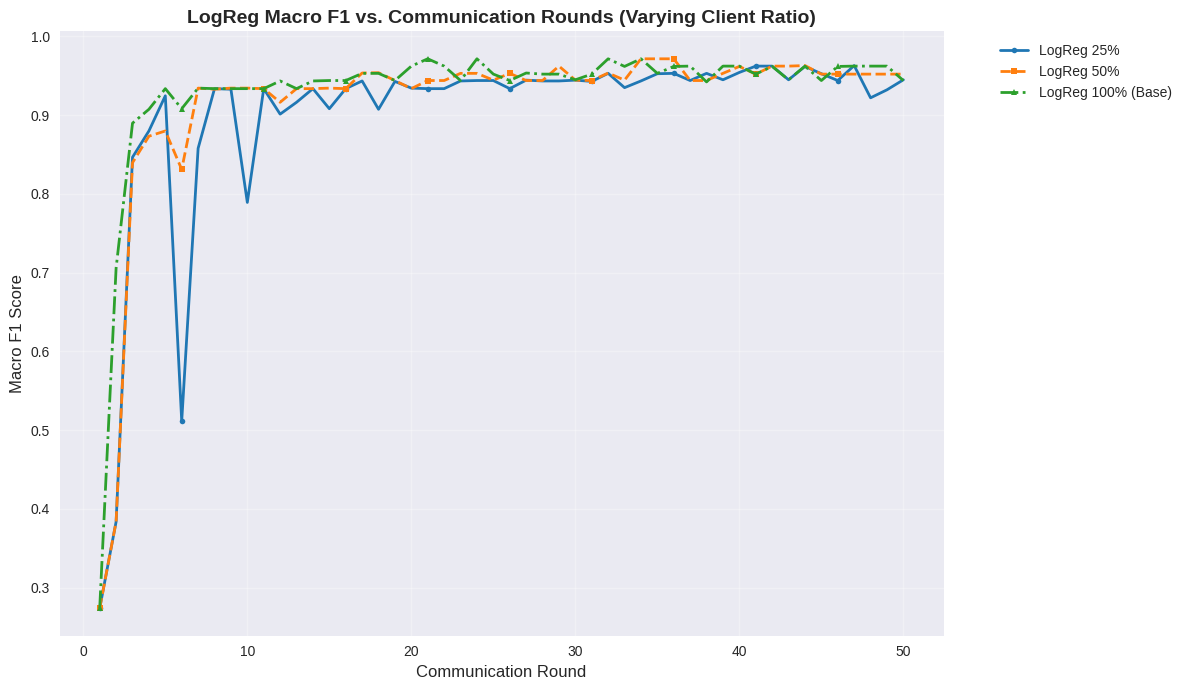

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_ratio_micro_f1.png


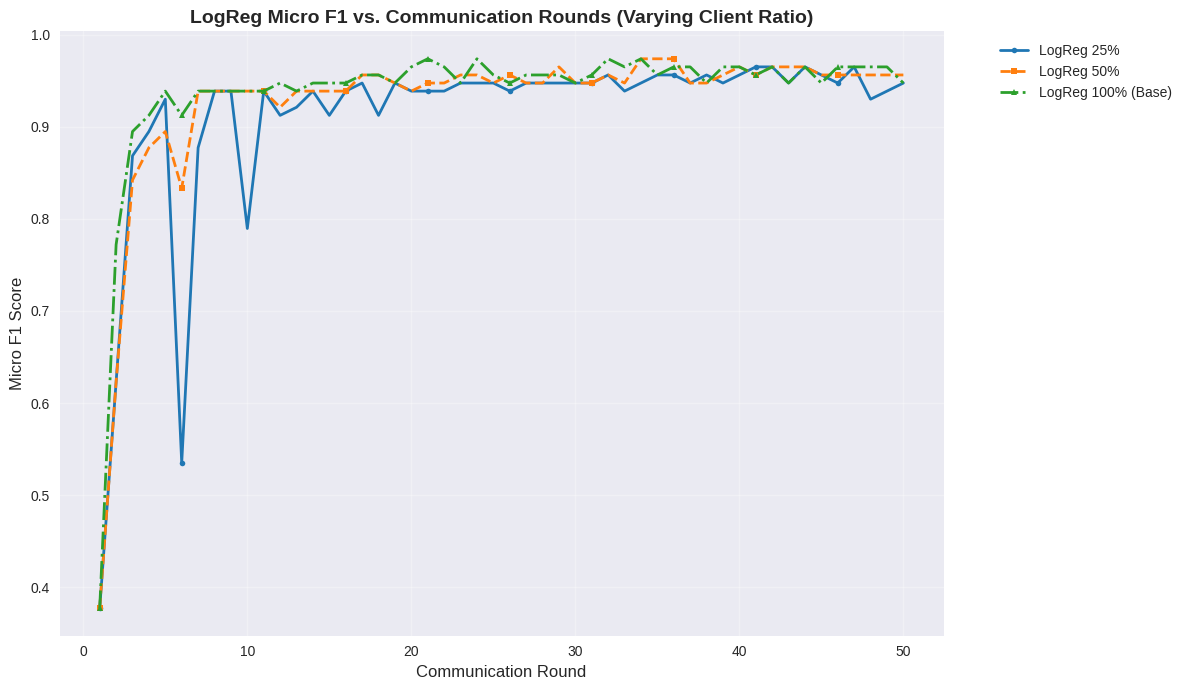

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/logreg_ratio_costs.png


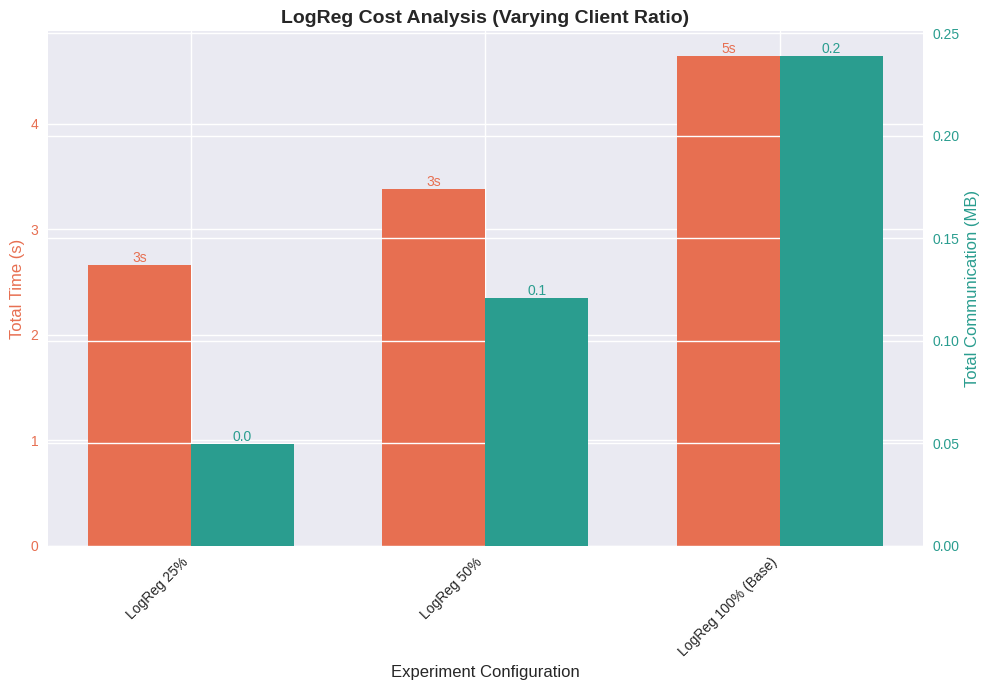

In [8]:
# LogReg Client Ratio Analysis
plot_evolution_metric(logreg_ratio_experiments, metric='accuracy', 
                      title='LogReg Validation Accuracy vs. Communication Rounds (Varying Client Ratio)',
                      filename='logreg_ratio_accuracy.png',
                      ylabel='Accuracy')

plot_evolution_metric(logreg_ratio_experiments, metric='macro_f1',
                      title='LogReg Macro F1 vs. Communication Rounds (Varying Client Ratio)',
                      filename='logreg_ratio_macro_f1.png',
                      ylabel='Macro F1 Score')

plot_evolution_metric(logreg_ratio_experiments, metric='micro_f1',
                      title='LogReg Micro F1 vs. Communication Rounds (Varying Client Ratio)',
                      filename='logreg_ratio_micro_f1.png',
                      ylabel='Micro F1 Score')

plot_cost_summary(logreg_ratio_experiments,
                  title='LogReg Cost Analysis (Varying Client Ratio)',
                  filename='logreg_ratio_costs.png')

---
## 5. Cross-Model Comparison: Accuracy & F1 over FL Rounds
Overlay **MLP** and **LogReg** (base configs) on the same plot.

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/model_cmp_accuracy_rounds.png


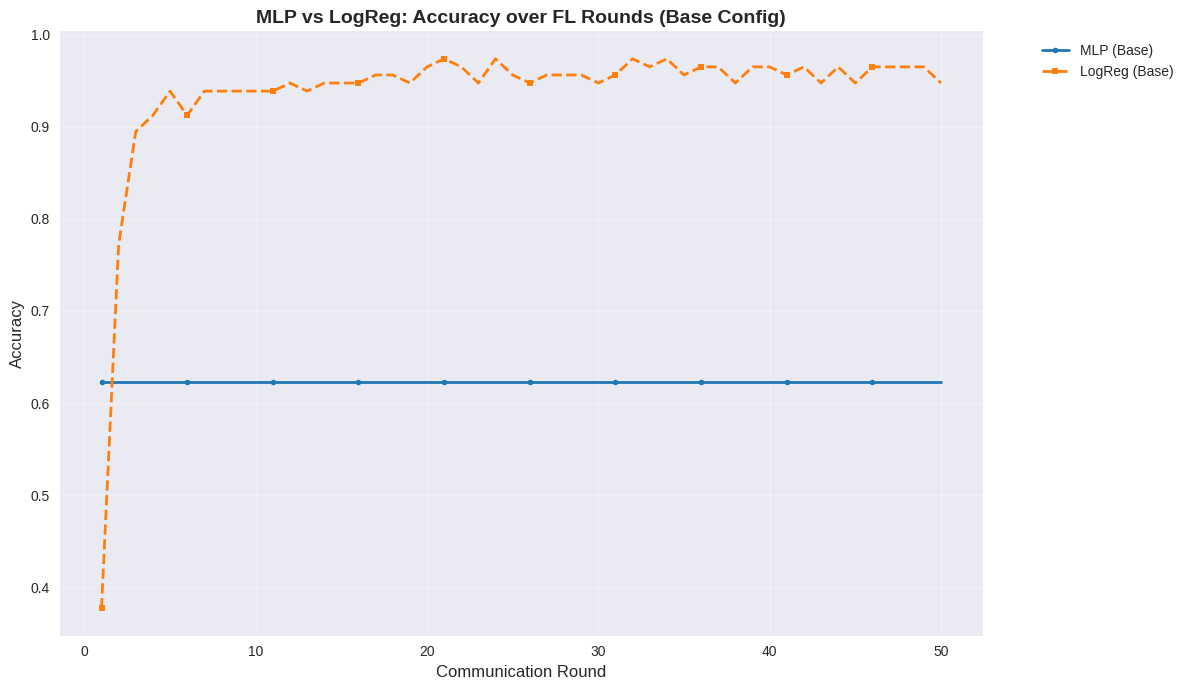

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/model_cmp_macro_f1_rounds.png


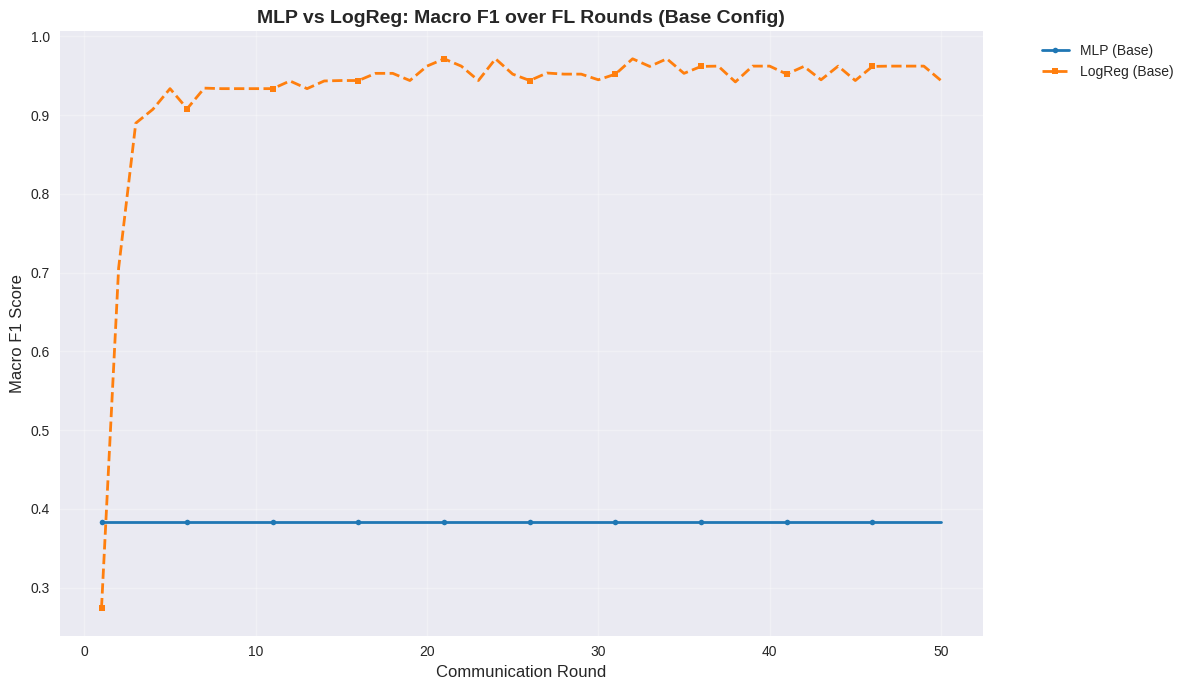

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/model_cmp_micro_f1_rounds.png


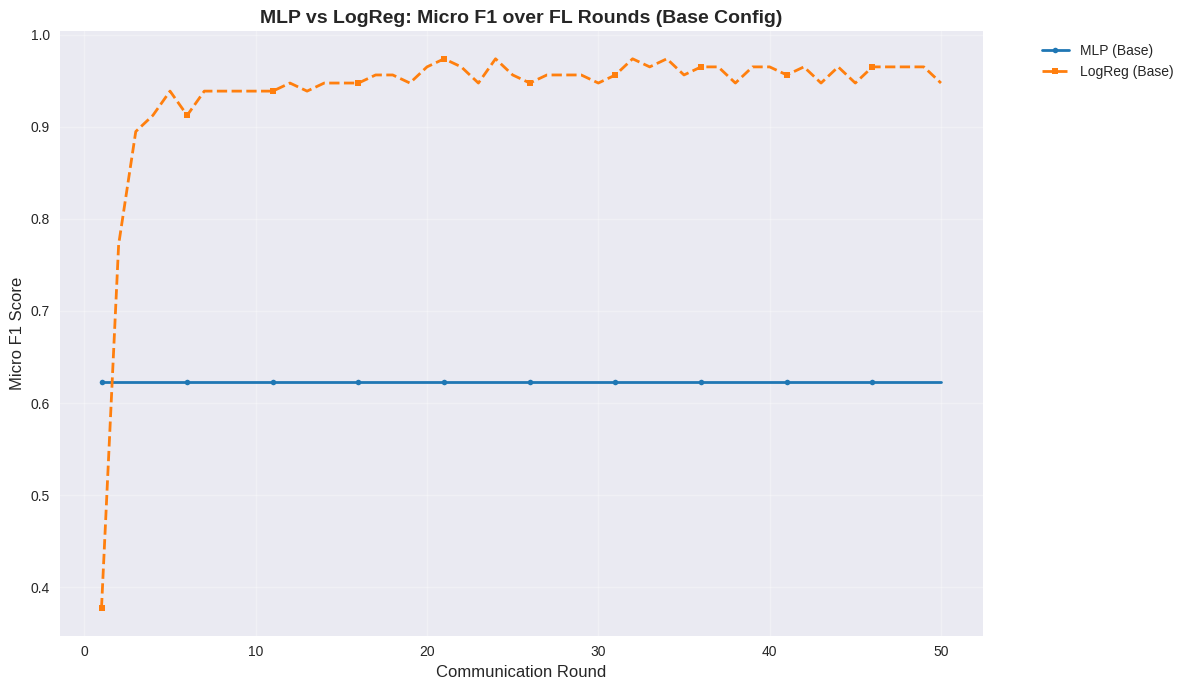

In [9]:
plot_evolution_metric(base_experiments, metric='accuracy',
                      title='MLP vs LogReg: Accuracy over FL Rounds (Base Config)',
                      filename='model_cmp_accuracy_rounds.png',
                      ylabel='Accuracy')

plot_evolution_metric(base_experiments, metric='macro_f1',
                      title='MLP vs LogReg: Macro F1 over FL Rounds (Base Config)',
                      filename='model_cmp_macro_f1_rounds.png',
                      ylabel='Macro F1 Score')

plot_evolution_metric(base_experiments, metric='micro_f1',
                      title='MLP vs LogReg: Micro F1 over FL Rounds (Base Config)',
                      filename='model_cmp_micro_f1_rounds.png',
                      ylabel='Micro F1 Score')

---
## 6. Utility (Accuracy) vs Cost (Training Time)
Scatter plots showing the trade-off between model quality and training cost.

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/utility_accuracy_vs_cost_epochs.png


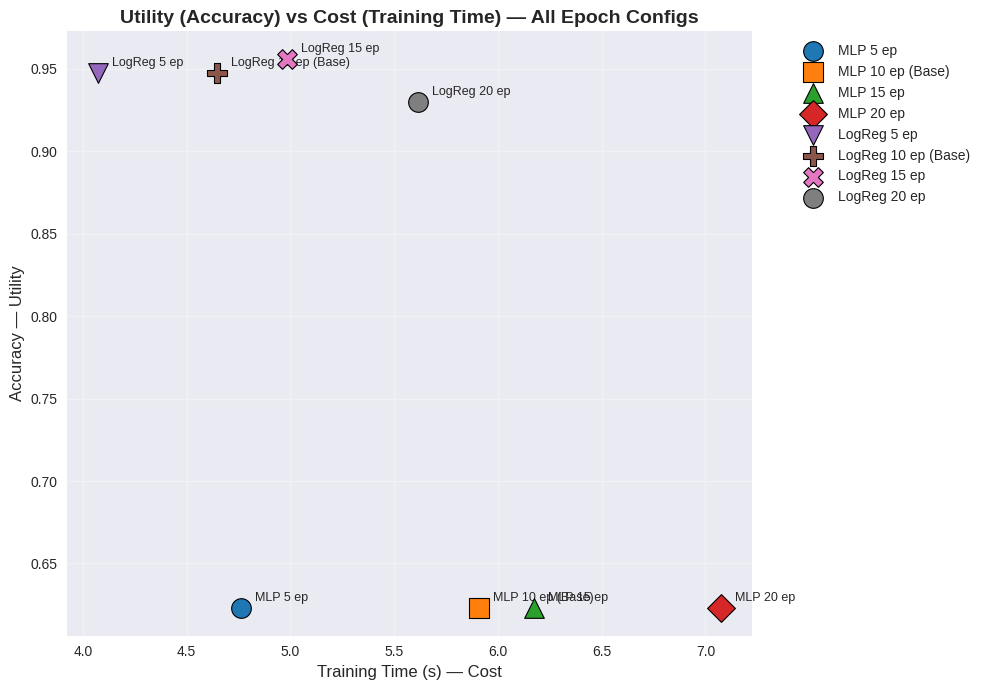

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/utility_macro_f1_vs_cost_epochs.png


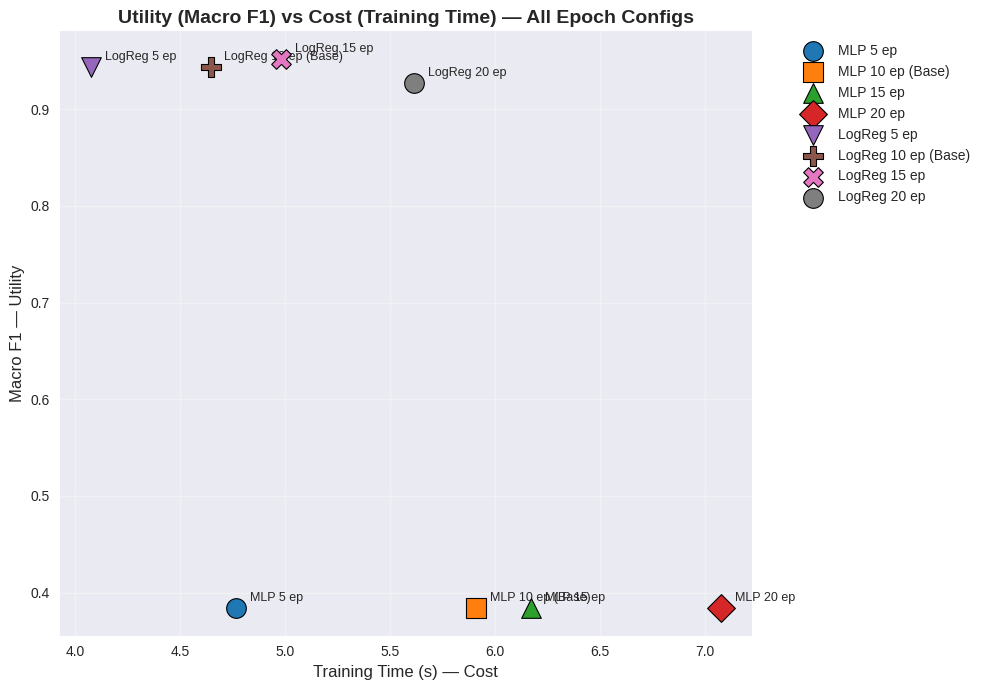

In [10]:
# Utility vs Cost — all epoch experiments
plot_utility_vs_cost(all_experiments, utility_metric='accuracy',
                     title='Utility (Accuracy) vs Cost (Training Time) \u2014 All Epoch Configs',
                     filename='utility_accuracy_vs_cost_epochs.png')

plot_utility_vs_cost(all_experiments, utility_metric='macro_f1',
                     title='Utility (Macro F1) vs Cost (Training Time) \u2014 All Epoch Configs',
                     filename='utility_macro_f1_vs_cost_epochs.png')

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/utility_accuracy_vs_cost_ratio.png


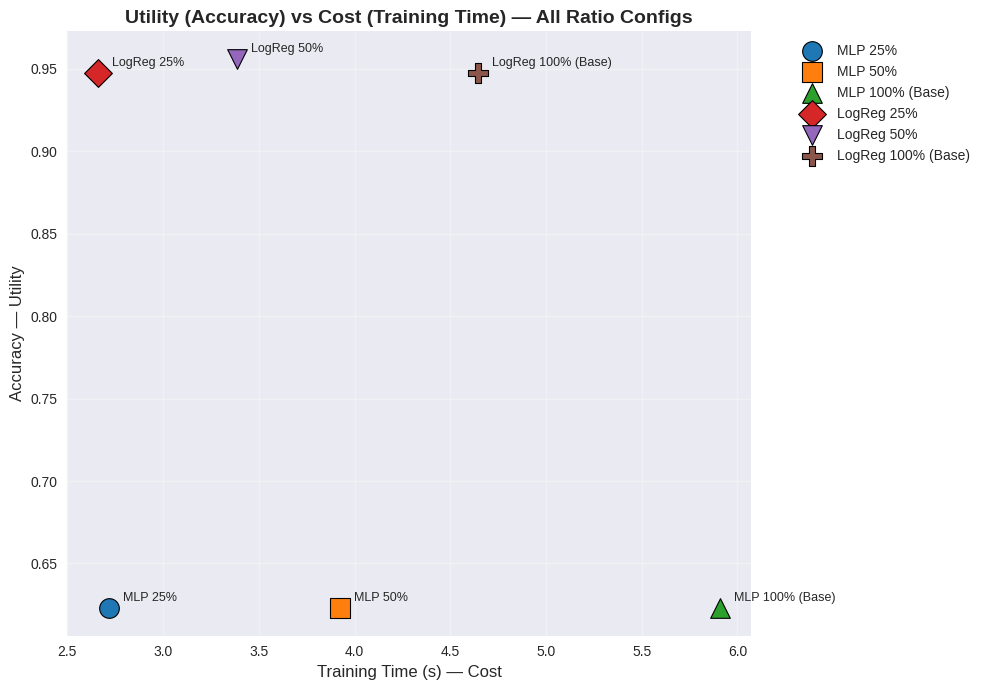

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/utility_macro_f1_vs_cost_ratio.png


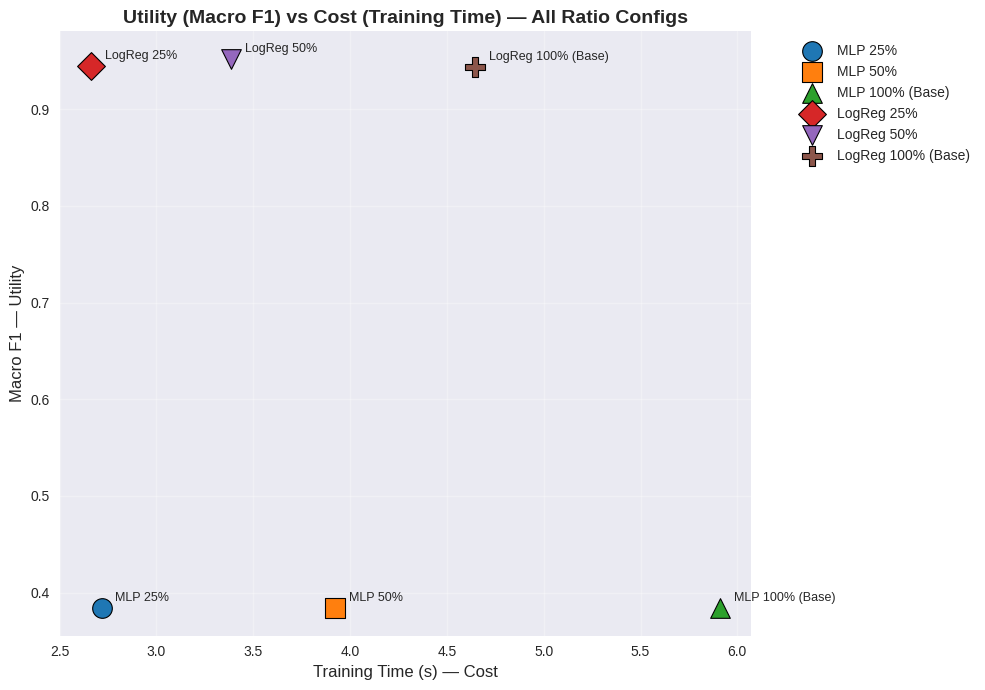

In [11]:
# Utility vs Cost — all ratio experiments
plot_utility_vs_cost(all_ratio_experiments, utility_metric='accuracy',
                     title='Utility (Accuracy) vs Cost (Training Time) \u2014 All Ratio Configs',
                     filename='utility_accuracy_vs_cost_ratio.png')

plot_utility_vs_cost(all_ratio_experiments, utility_metric='macro_f1',
                     title='Utility (Macro F1) vs Cost (Training Time) \u2014 All Ratio Configs',
                     filename='utility_macro_f1_vs_cost_ratio.png')

---
## 7. Accuracy / Local Epochs  (per model)
How does the number of local epochs affect final accuracy?

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/accuracy_vs_epochs.png


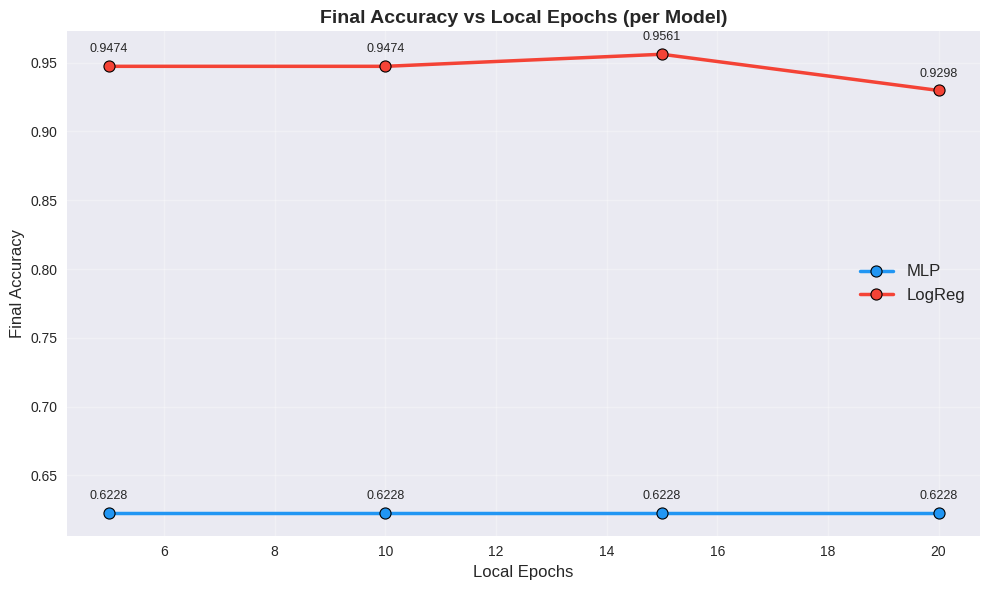

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/best_accuracy_vs_epochs.png


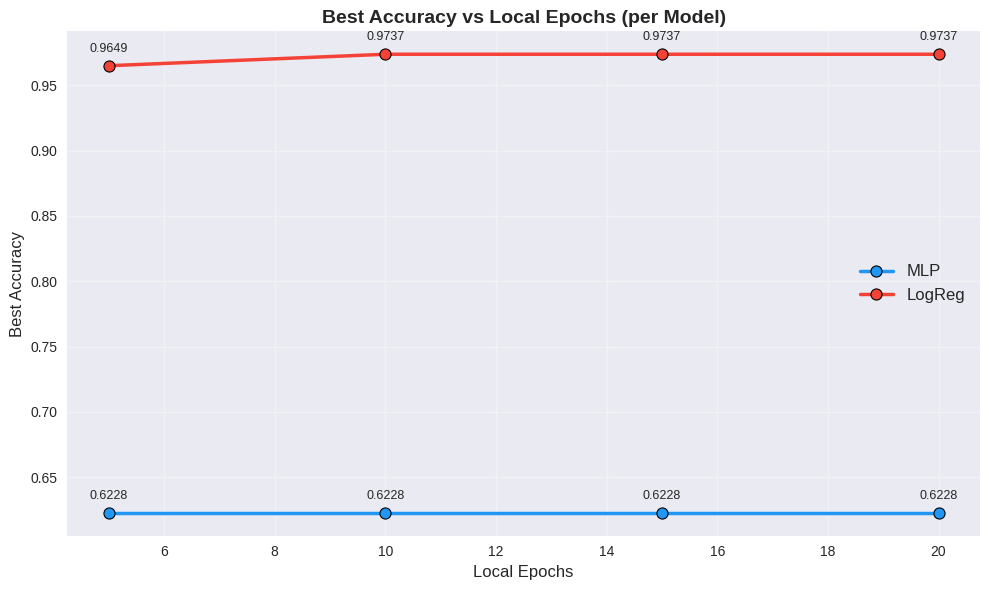

In [12]:
plot_metric_vs_param(epochs_by_model, param_name='Local Epochs', metric='accuracy',
                     title='Final Accuracy vs Local Epochs (per Model)',
                     filename='accuracy_vs_epochs.png',
                     ylabel='Final Accuracy')

plot_metric_vs_param(epochs_by_model, param_name='Local Epochs', metric='accuracy',
                     title='Best Accuracy vs Local Epochs (per Model)',
                     filename='best_accuracy_vs_epochs.png',
                     ylabel='Best Accuracy', use_best=True)

## 8. F1 Score / Local Epochs  (per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/macro_f1_vs_epochs.png


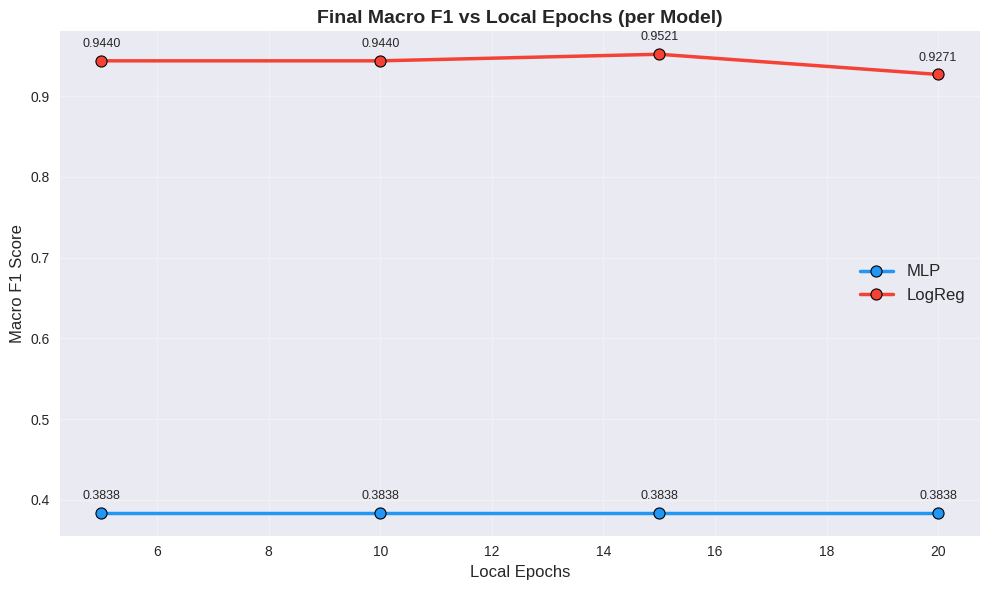

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/micro_f1_vs_epochs.png


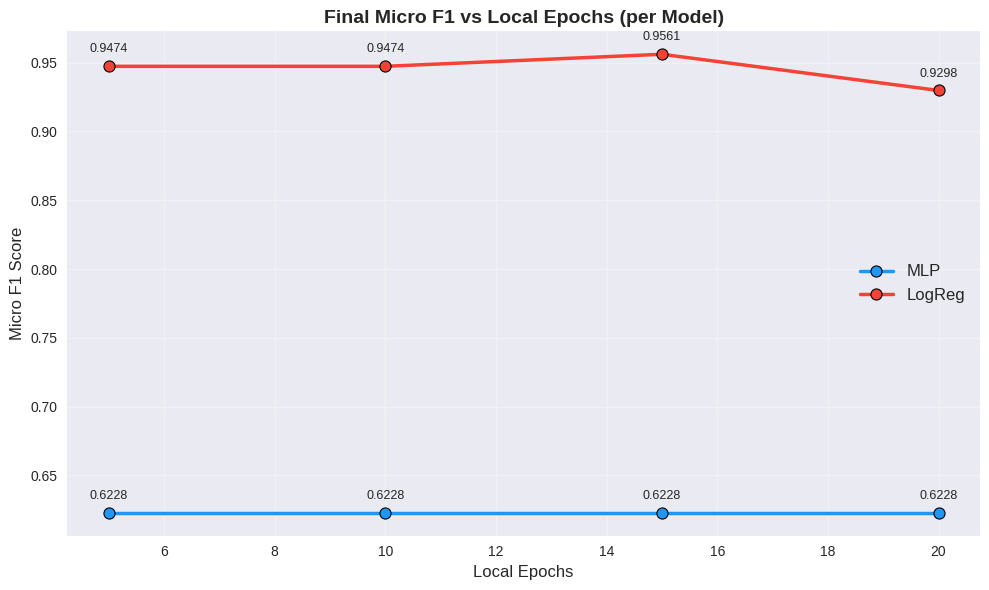

In [13]:
plot_metric_vs_param(epochs_by_model, param_name='Local Epochs', metric='macro_f1',
                     title='Final Macro F1 vs Local Epochs (per Model)',
                     filename='macro_f1_vs_epochs.png',
                     ylabel='Macro F1 Score')

plot_metric_vs_param(epochs_by_model, param_name='Local Epochs', metric='micro_f1',
                     title='Final Micro F1 vs Local Epochs (per Model)',
                     filename='micro_f1_vs_epochs.png',
                     ylabel='Micro F1 Score')

## 9. Training Time / Local Epochs  (per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/train_time_vs_epochs.png


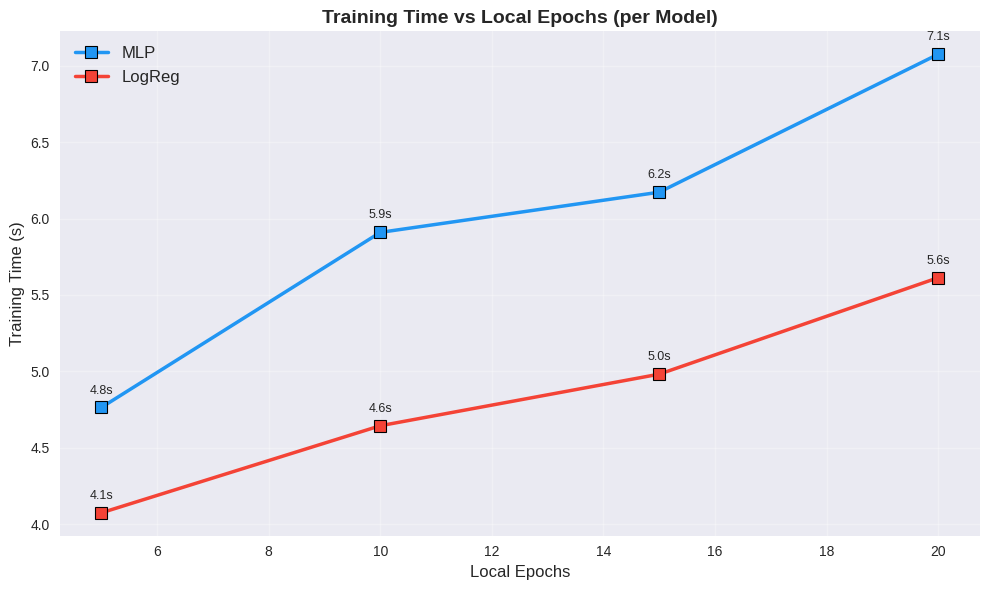

In [14]:
plot_time_vs_param(epochs_by_model, param_name='Local Epochs',
                   title='Training Time vs Local Epochs (per Model)',
                   filename='train_time_vs_epochs.png')

---
## 10. Accuracy / Client Ratio  (per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/accuracy_vs_ratio.png


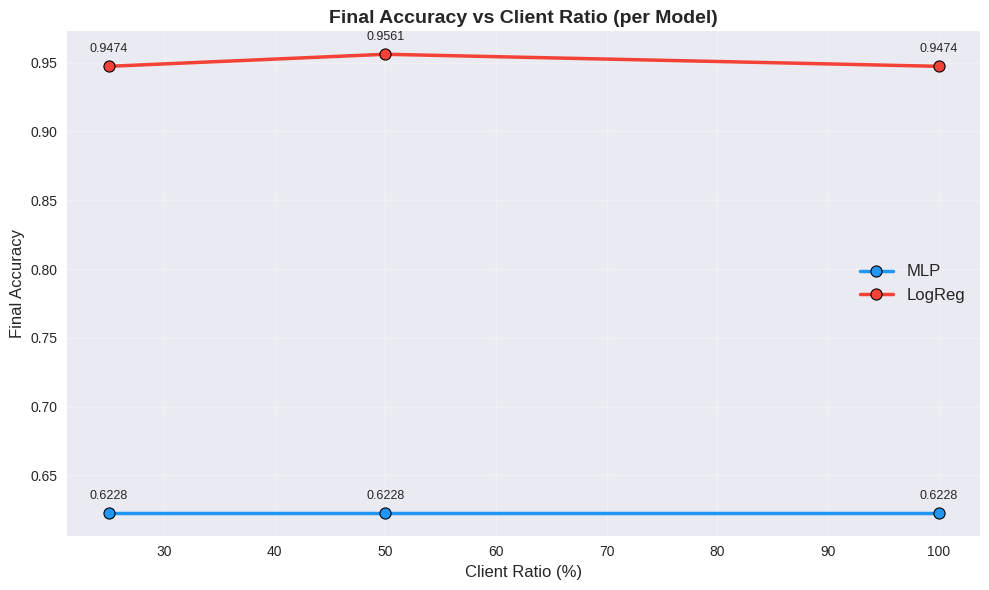

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/best_accuracy_vs_ratio.png


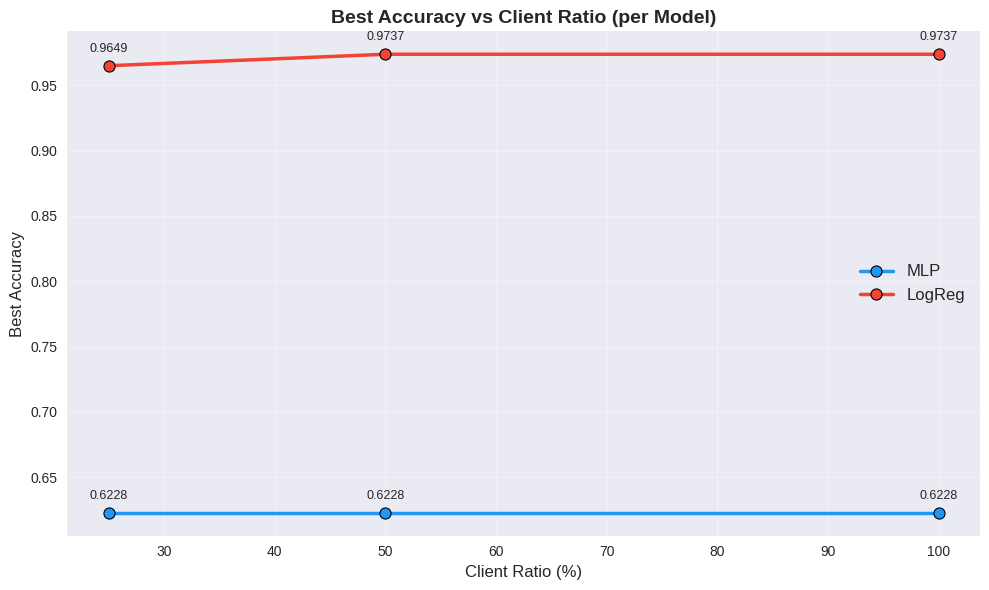

In [15]:
plot_metric_vs_param(ratio_by_model, param_name='Client Ratio (%)', metric='accuracy',
                     title='Final Accuracy vs Client Ratio (per Model)',
                     filename='accuracy_vs_ratio.png',
                     ylabel='Final Accuracy')

plot_metric_vs_param(ratio_by_model, param_name='Client Ratio (%)', metric='accuracy',
                     title='Best Accuracy vs Client Ratio (per Model)',
                     filename='best_accuracy_vs_ratio.png',
                     ylabel='Best Accuracy', use_best=True)

## 11. F1 Score / Client Ratio  (per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/macro_f1_vs_ratio.png


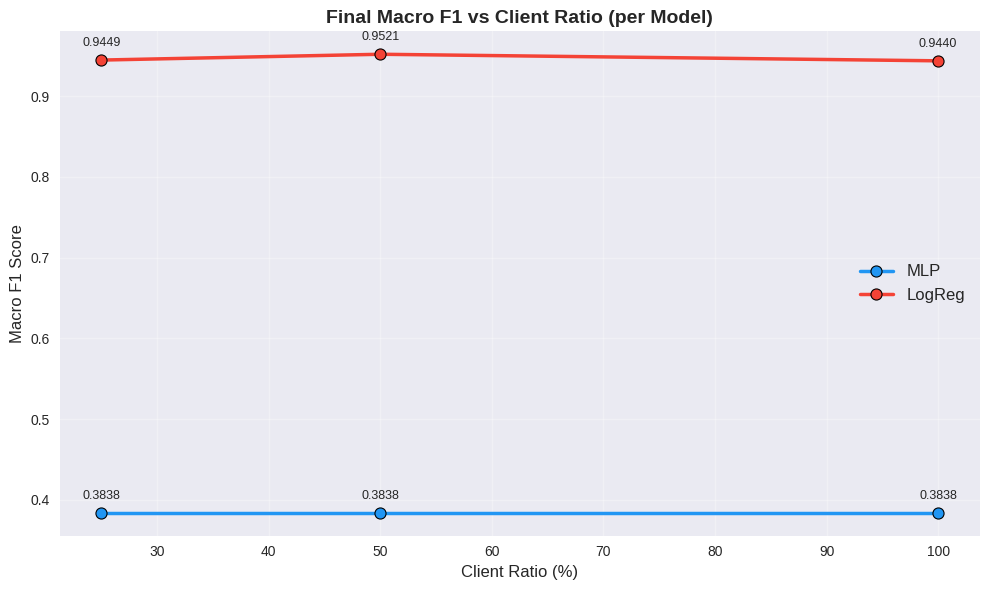

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/micro_f1_vs_ratio.png


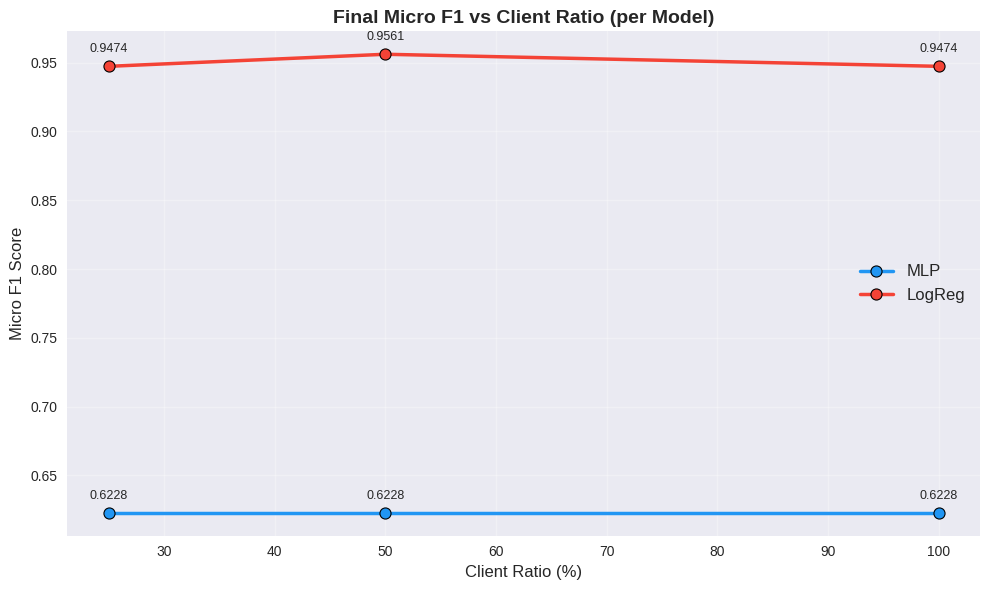

In [16]:
plot_metric_vs_param(ratio_by_model, param_name='Client Ratio (%)', metric='macro_f1',
                     title='Final Macro F1 vs Client Ratio (per Model)',
                     filename='macro_f1_vs_ratio.png',
                     ylabel='Macro F1 Score')

plot_metric_vs_param(ratio_by_model, param_name='Client Ratio (%)', metric='micro_f1',
                     title='Final Micro F1 vs Client Ratio (per Model)',
                     filename='micro_f1_vs_ratio.png',
                     ylabel='Micro F1 Score')

## 12. Training Time / Client Ratio  (per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/train_time_vs_ratio.png


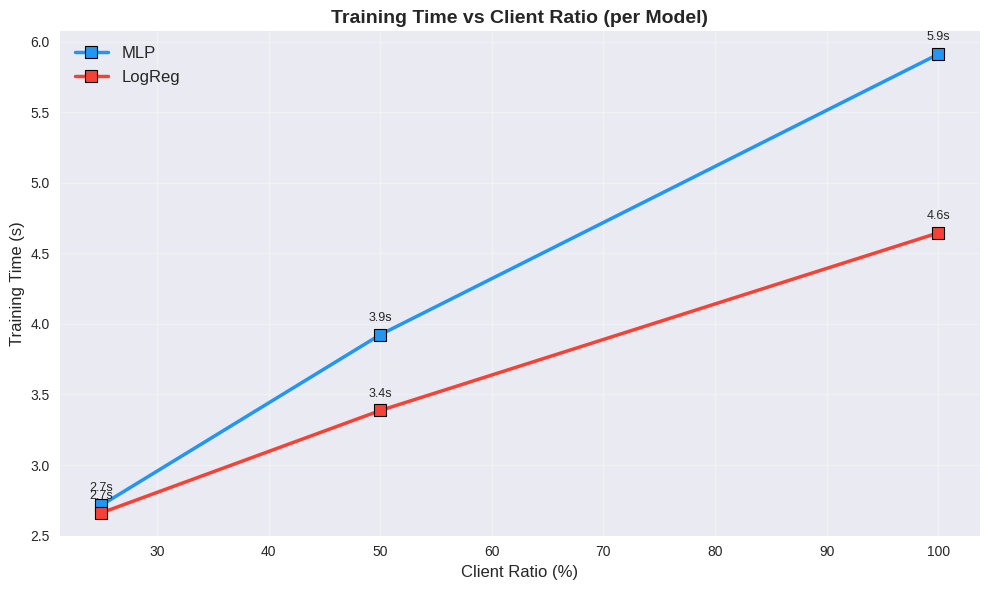

In [17]:
plot_time_vs_param(ratio_by_model, param_name='Client Ratio (%)',
                   title='Training Time vs Client Ratio (per Model)',
                   filename='train_time_vs_ratio.png')

---
## 13. Grouped Bar Charts — Local Epochs (side-by-side per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/grouped_accuracy_epochs.png


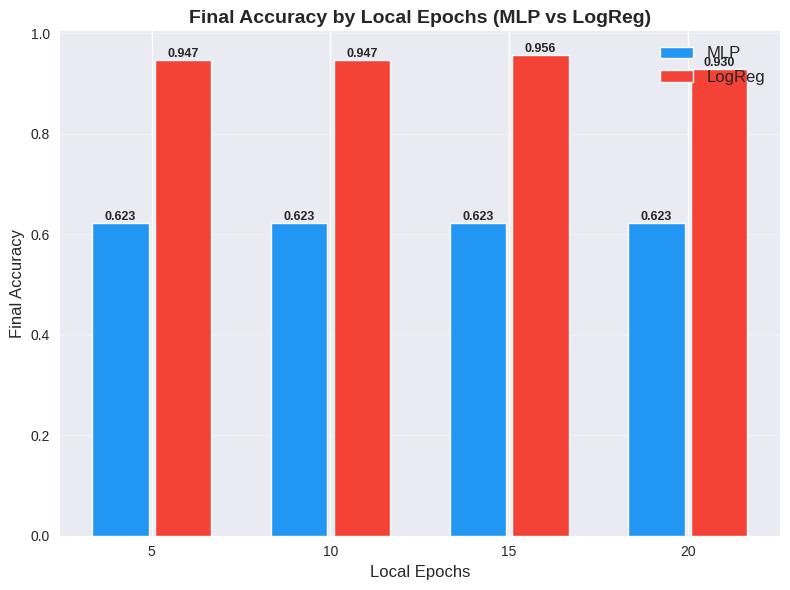

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/grouped_macro_f1_epochs.png


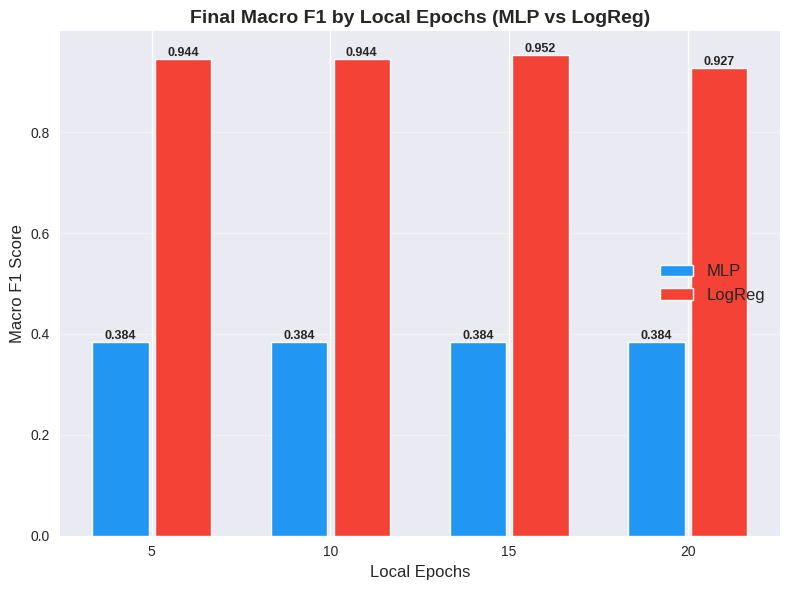

In [18]:
plot_grouped_bars(epochs_by_model, param_name='Local Epochs', metric='accuracy',
                  title='Final Accuracy by Local Epochs (MLP vs LogReg)',
                  filename='grouped_accuracy_epochs.png',
                  ylabel='Final Accuracy')

plot_grouped_bars(epochs_by_model, param_name='Local Epochs', metric='macro_f1',
                  title='Final Macro F1 by Local Epochs (MLP vs LogReg)',
                  filename='grouped_macro_f1_epochs.png',
                  ylabel='Macro F1 Score')

## 14. Grouped Bar Charts — Client Ratio (side-by-side per model)

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/grouped_accuracy_ratio.png


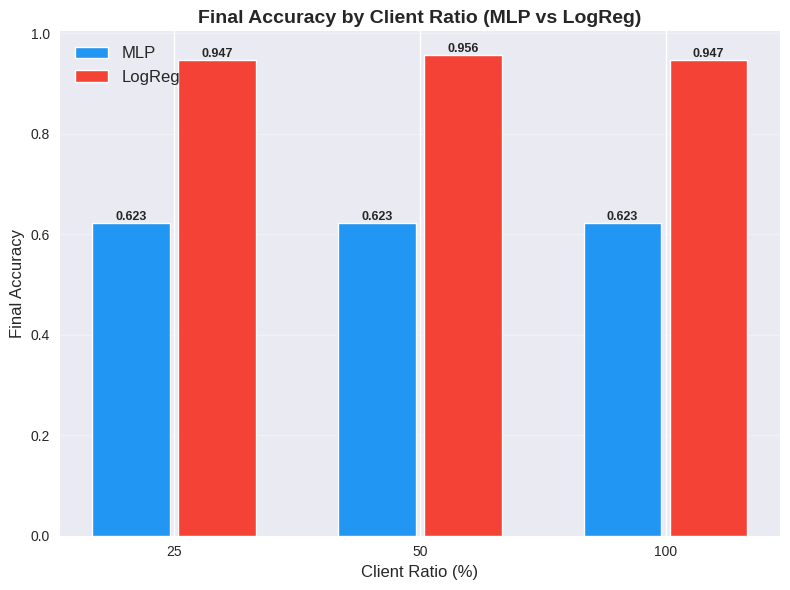

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/grouped_macro_f1_ratio.png


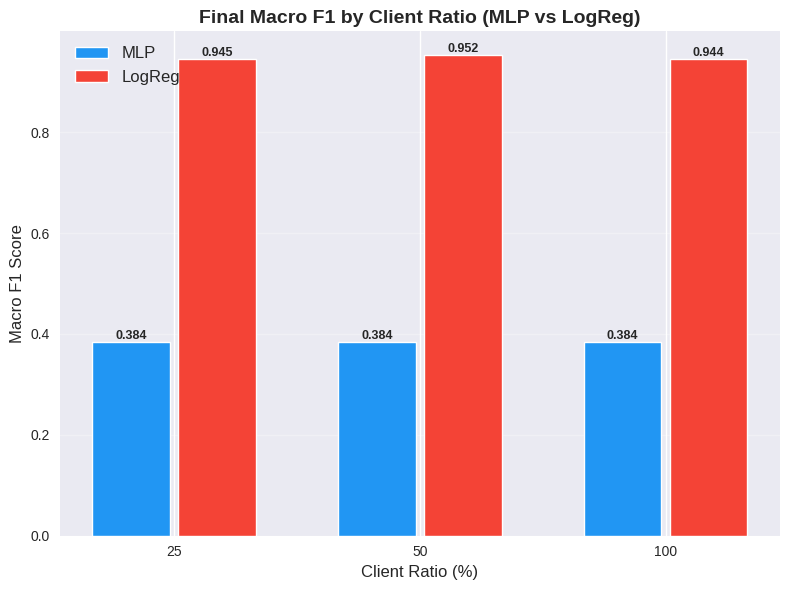

In [19]:
plot_grouped_bars(ratio_by_model, param_name='Client Ratio (%)', metric='accuracy',
                  title='Final Accuracy by Client Ratio (MLP vs LogReg)',
                  filename='grouped_accuracy_ratio.png',
                  ylabel='Final Accuracy')

plot_grouped_bars(ratio_by_model, param_name='Client Ratio (%)', metric='macro_f1',
                  title='Final Macro F1 by Client Ratio (MLP vs LogReg)',
                  filename='grouped_macro_f1_ratio.png',
                  ylabel='Macro F1 Score')

---
## 15. Summary Tables

In [20]:
print("=" * 80)
print("LOCAL EPOCHS SWEEP — Summary")
print("=" * 80)

rows = []
for model_name, entries in epochs_by_model.items():
    for param_val, run_path in entries:
        p = Path(run_path)
        df = load_global_metrics(p)
        t = load_run_time(p)
        comm = comm_to_mb(load_comm_costs(p))
        if df is not None:
            rows.append({
                'Model': model_name,
                'Local Epochs': param_val,
                'Final Accuracy': f"{df['accuracy'].iloc[-1]:.4f}",
                'Best Accuracy': f"{df['accuracy'].max():.4f}",
                'Final Macro F1': f"{df['macro_f1'].iloc[-1]:.4f}",
                'Final Micro F1': f"{df['micro_f1'].iloc[-1]:.4f}",
                'Train Time (s)': f"{t:.1f}",
                'Comm (MB)': f"{comm:.1f}",
            })

epochs_summary = pd.DataFrame(rows)
display(epochs_summary)

LOCAL EPOCHS SWEEP — Summary


,Model,Local Epochs,Final Accuracy,Best Accuracy,Final Macro F1,Final Micro F1,Train Time (s),Comm (MB)
0,MLP,5,0.6228,0.6228,0.3838,0.6228,4.8,15.9
1,MLP,10,0.6228,0.6228,0.3838,0.6228,5.9,15.9
2,MLP,15,0.6228,0.6228,0.3838,0.6228,6.2,15.9
3,MLP,20,0.6228,0.6228,0.3838,0.6228,7.1,15.9
4,LogReg,5,0.9474,0.9649,0.9440,0.9474,4.1,0.2
5,LogReg,10,0.9474,0.9737,0.9440,0.9474,4.6,0.2
6,LogReg,15,0.9561,0.9737,0.9521,0.9561,5.0,0.2
7,LogReg,20,0.9298,0.9737,0.9271,0.9298,5.6,0.2


In [21]:
print("=" * 80)
print("CLIENT RATIO SWEEP — Summary")
print("=" * 80)

rows = []
for model_name, entries in ratio_by_model.items():
    for param_val, run_path in entries:
        p = Path(run_path)
        df = load_global_metrics(p)
        t = load_run_time(p)
        comm = comm_to_mb(load_comm_costs(p))
        if df is not None:
            rows.append({
                'Model': model_name,
                'Client Ratio (%)': param_val,
                'Final Accuracy': f"{df['accuracy'].iloc[-1]:.4f}",
                'Best Accuracy': f"{df['accuracy'].max():.4f}",
                'Final Macro F1': f"{df['macro_f1'].iloc[-1]:.4f}",
                'Final Micro F1': f"{df['micro_f1'].iloc[-1]:.4f}",
                'Train Time (s)': f"{t:.1f}",
                'Comm (MB)': f"{comm:.1f}",
            })

ratio_summary = pd.DataFrame(rows)
display(ratio_summary)

CLIENT RATIO SWEEP — Summary


,Model,Client Ratio (%),Final Accuracy,Best Accuracy,Final Macro F1,Final Micro F1,Train Time (s),Comm (MB)
0,MLP,25,0.6228,0.6228,0.3838,0.6228,2.7,3.3
1,MLP,50,0.6228,0.6228,0.3838,0.6228,3.9,8.0
2,MLP,100,0.6228,0.6228,0.3838,0.6228,5.9,15.9
3,LogReg,25,0.9474,0.9649,0.9449,0.9474,2.7,0.0
4,LogReg,50,0.9561,0.9737,0.9521,0.9561,3.4,0.1
5,LogReg,100,0.9474,0.9737,0.9440,0.9474,4.6,0.2
